# Part 9 (HFooladi-style): BasicGCN for MDM2 Classification

Colab-ready, self-contained replication of HFooladi/GNNs-For-Chemists (9-dim atom feats, `BasicGCN`, 80/10/10 split seed 42, batch 32, Adam, BCEWithLogitsLoss, best-val-AUC) on the local MDM2 set (`ro5_properties_filtered.csv`).

Run cells top to bottom: install → train → evaluate → screen. Set `EPOCHS = 2` in the training cell for a smoke test.


## 1. Install (Colab)


In [1]:
!pip install -q torch-geometric rdkit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 61.9 MB/s eta 0:00:00:00:0100:01


## 2. Get the repo data (Colab)
If you opened this notebook directly from GitHub, this clones the repo so `ro5_properties_filtered.csv` is found automatically. Set `REPO_URL` to your fork if needed. Skip if the file is already present.


In [2]:
import os
import subprocess

# --- Setup: make sure the repo (and the MDM2 CSV) exists locally ---
# If you opened this notebook straight from GitHub in Colab, the data file is
# not present yet -- the cell below clones it automatically.
# Edit REPO_URL only if your repo lives somewhere else.
REPO_URL = "https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git"
REPO_DIR = os.path.basename(REPO_URL).replace(".git", "")


def _find_csv(fname="ro5_properties_filtered.csv", roots=None):
    roots = roots or [os.getcwd(), "/content"]
    for r in roots:
        if not os.path.isdir(r):
            continue
        for dirpath, dirnames, filenames in os.walk(r):
            if ".git" in dirnames:
                dirnames.remove(".git")
            if fname in filenames:
                return os.path.join(dirpath, fname)
            if dirpath.replace(r, "").count(os.sep) >= 3:
                dirnames[:] = []
    return None


if _find_csv() is None and os.path.isdir(REPO_DIR):
    print(f"{REPO_DIR}/ already cloned.")
elif _find_csv() is None:
    print(f"Cloning {REPO_URL} ...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=False)
print("CSV:", _find_csv() or "NOT FOUND (upload it when asked below)")


Cloning https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git ...
CSV: /content/Natural_MDM2_Inhibitor_Discovery_using_ML/Part_2/ro5_properties_filtered.csv


In [ ]:
# === Retrofit flags — TASK/both + Delta + filtering + screening (flag-only, reference patterns) ===
TASK = "both"  # "classification" | "regression" | "both" (both = ONE regression run + derived 0/1 at CLASS_THRESHOLD)
USE_DELTA = True
CLASS_THRESHOLD = 7.0  # Active <=> pIC50 >= 7.0 (645-row ro5_properties_filtered.csv)
WEIGHT_DECAY = 1e-4  # unified flag (reuses existing 1e-4 value — now flaggable)
EARLY_STOP = True
PATIENCE = 15
USE_EARLY_STOPPING = EARLY_STOP
EARLY_STOP_PATIENCE = PATIENCE
AUGMENT_N = 2
FILTER_DUP_SMILES = True
FILTER_PIC50_OUTLIER = False
FILTER_INVALID_PIC50 = True
RIDGE_ALPHA = 1.0
PRED_CAP = 10.0
APPLICABILITY_DOMAIN_FILTER = False
STRICT_MEDCHEM = False
FAST_MODE = False
USE_MACCS = False
USE_MORGAN = False
TARGET_COL = "pIC50"
print(f'TASK={TASK} | USE_DELTA={USE_DELTA} | CLASS_THRESHOLD={CLASS_THRESHOLD} | WEIGHT_DECAY={WEIGHT_DECAY} | EARLY_STOP={EARLY_STOP}:{PATIENCE} | AUGMENT_N={AUGMENT_N} | DUP={FILTER_DUP_SMILES} OUTLIER={FILTER_PIC50_OUTLIER} INVALID={FILTER_INVALID_PIC50} | RIDGE_ALPHA={RIDGE_ALPHA} | PRED_CAP={PRED_CAP} | AD={APPLICABILITY_DOMAIN_FILTER} | STRICT_MEDCHEM={STRICT_MEDCHEM} | FAST_MODE={FAST_MODE} | MACCS={USE_MACCS} MORGAN={USE_MORGAN}')


## 2. Imports + paths
Works from the repo root (`Part_9/` auto-detected) or from inside `Part_9/` itself — e.g. after cloning your repo in Colab and `%cd`-ing into it.


In [3]:
"""Part 9 (HFooladi-exact): BasicGCN for MDM2 inhibitor classification.

Faithful replication of HFooladi/GNNs-For-Chemists notebook 04
(`04_GNN_GCN.ipynb`) applied to the local MDM2 dataset:

* Featurization — byte-identical to notebook 04 / ``notebooks/utils/featurization.py``:
  9-dim integer atom features (atomic num, chirality, degree, formal charge,
  num Hs, radical electrons, hybridization, aromaticity, ring) + 3-dim bond
  features (bond type, conjugation, ring). ``mol_to_graph(smiles)`` signature
  and body are unchanged.
* Model — ``BasicGCN`` identical to notebook 04: conv1 + (num_layers-1) hidden
  ``GCNConv`` layers, ``global_mean_pool``, two-layer MLP head (lin1+ReLU+lin2).
* Training — BBBP-style classification loop from notebook 06
  (``BCEWithLogitsLoss``, val-AUC best-model selection), because MDM2 is a
  binary classification task like BBBP (notebook 04 itself trains ESOL
  regression with MSELoss, which does not apply here):
  80/10/10 random split (seed 42), ``DataLoader`` batch 32, Adam, 100 epochs.

Dataset: ``Part_9/ro5_properties_filtered.csv`` (645 MDM2 compounds,
``bioactivity_class`` -> y in {0, 1}).

Usage:
    python train_gcn_hfooladi.py            # train, evaluate, save model+plots
    python train_gcn_hfooladi.py --epochs 100 --hidden 64 --layers 3
    python train_gcn_hfooladi.py --screen input.csv --screen-out preds.csv
"""
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

BASE = os.path.dirname(_find_csv())
DATA_CSV = _find_csv()
if DATA_CSV is None:
    # Last resort: ask for the file.
    BASE = os.getcwd()
    DATA_CSV = os.path.join(BASE, "ro5_properties_filtered.csv")
    try:
        from google.colab import files as _cf
        print(f"{DATA_CSV} not found. Please upload ro5_properties_filtered.csv:")
        _up = _cf.upload()
        _name = list(_up.keys())[0]
        if os.path.basename(_name) == os.path.basename(DATA_CSV):
            with open(DATA_CSV, "wb") as _f:
                _f.write(_up[_name])
        else:
            DATA_CSV = _name
        print(f"Using {DATA_CSV}")
    except ImportError:
        raise FileNotFoundError(
            f"{DATA_CSV} not found. Put ro5_properties_filtered.csv in {BASE} "
            "next to the notebook (or %cd to the repo root).")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------------------------
# Featurization — identical to HFooladi notebook 04
# ---------------------------------------------------------------------------
def atom_features(atom):
    """Extract a feature vector for an RDKit atom (shape (9,), dtype long)."""
    return torch.tensor([
        atom.GetAtomicNum(),
        int(atom.GetChiralTag()),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalNumHs(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
    ], dtype=torch.long)


def bond_features(bond):
    """Extract a feature vector for an RDKit bond (shape (3,), dtype long)."""
    return torch.tensor([
        int(bond.GetBondTypeAsDouble()),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ], dtype=torch.long)


def mol_to_graph(smiles):
    """Convert a SMILES into a PyTorch Geometric graph (undirected, 2 directed
    edges per bond). Returns Data(x [N,9], edge_index [2,E], edge_attr [E,3])."""
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index.append((i, j))
        edge_index.append((j, i))
        edge_attr.append(bond_features(bond))
        edge_attr.append(bond_features(bond))
    if edge_index:  # guard for single-atom molecules (no bonds); HFooladi's
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()  # tutorial set has none
        edge_attr = torch.stack(edge_attr, dim=0)
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 3), dtype=torch.long)  # fix: keep tensor so Batch collation succeeds (was None -> KeyError)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, smiles=smiles)


def mol_to_graph_labeled(smiles, y):
    """mol_to_graph + float label ``y`` of shape [1] for BCEWithLogitsLoss."""
    try:
        d = mol_to_graph(smiles)
    except ValueError:
        return None
    d.y = torch.tensor([[float(y)]], dtype=torch.float)
    return d




## 3. Model — `BasicGCN` (identical to HFooladi)


In [4]:
# ---------------------------------------------------------------------------
# Model — identical to HFooladi notebook 04 BasicGCN
# ---------------------------------------------------------------------------
class BasicGCN(nn.Module):
    """Basic GCN: input GCN layer + hidden GCN layers, mean pooling, 2-layer MLP."""

    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super(BasicGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.convs = nn.ModuleList()
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.lin1 = nn.Linear(hidden_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        x = self.lin2(x)
        return x




## 4. Training loop + data helpers (identical to HFooladi notebook 06)


In [5]:
# ---------------------------------------------------------------------------
# Training — BBBP classification loop from HFooladi notebook 06
# (BCEWithLogitsLoss, best-val-AUC checkpointing)
# ---------------------------------------------------------------------------
def train_and_evaluate(model, optimizer, train_loader, val_loader, test_loader,
                       dev, epochs=100):
    """Train and evaluate a model for molecular property prediction."""
    train_losses, val_losses, val_aucs = [], [], []
    best_val_auc, best_model = 0, None
    _no_improve = 0  # retrofit: early stopping counter (val AUC, patience 15, restore best)
    _PATIENCE = int(globals().get("PATIENCE", globals().get("EARLY_STOP_PATIENCE", 15)))
    _EARLY_STOP = bool(globals().get("EARLY_STOP", globals().get("USE_EARLY_STOPPING", True)))
    criterion = nn.BCEWithLogitsLoss()
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_samples = 0, 0
        for data in train_loader:
            optimizer.zero_grad()
            data = data.to(dev)
            out = model(data.x.float(), data.edge_index, data.batch)
            if out.size(0) != data.y.size(0):
                m = min(out.size(0), data.y.size(0))
                out, data.y = out[:m], data.y[:m]
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
            total_samples += data.num_graphs
        avg_loss = total_loss / total_samples
        train_losses.append(avg_loss)

        model.eval()
        val_loss, val_samples, y_true, y_pred = 0, 0, [], []
        with torch.no_grad():
            for data in val_loader:
                data = data.to(dev)
                out = model(data.x.float(), data.edge_index, data.batch)
                if out.size(0) != data.y.size(0):
                    m = min(out.size(0), data.y.size(0))
                    out, data.y = out[:m], data.y[:m]
                loss = criterion(out, data.y)
                val_loss += loss.item() * data.num_graphs
                val_samples += data.num_graphs
                y_true.append(data.y.cpu().numpy())
                y_pred.append(torch.sigmoid(out).cpu().numpy())
        avg_val_loss = val_loss / val_samples
        val_losses.append(avg_val_loss)
        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        val_auc = roc_auc_score(y_true, y_pred)
        val_aucs.append(val_auc)
        if val_auc > best_val_auc + 1e-4:
            best_val_auc = val_auc
            best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            _no_improve = 0
        else:
            _no_improve += 1
        if _EARLY_STOP and _no_improve >= _PATIENCE:
            print(f"Early stopping at epoch {epoch} (best Val AUC {best_val_auc:.4f}, patience {_PATIENCE})", flush=True)
            break
        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d}: Train Loss: {avg_loss:.4f}, "
                  f"Val Loss: {avg_val_loss:.4f}, Val AUC: {val_auc:.4f}", flush=True)

    if best_model is not None:
        model.load_state_dict(best_model)
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for data in test_loader:
            data = data.to(dev)
            out = model(data.x.float(), data.edge_index, data.batch)
            if out.size(0) != data.y.size(0):
                m = min(out.size(0), data.y.size(0))
                out, data.y = out[:m], data.y[:m]
            y_true.append(data.y.cpu().numpy())
            y_pred.append(torch.sigmoid(out).cpu().numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    test_auc = roc_auc_score(y_true, y_pred)
    return {"train_losses": train_losses, "val_losses": val_losses,
            "val_aucs": val_aucs, "best_val_auc": best_val_auc,
            "test_auc": test_auc, "y_true": y_true, "y_pred": y_pred}


def load_mdm2_graphs(csv_path=DATA_CSV):
    df = pd.read_csv(csv_path)
    df["y"] = (df["bioactivity_class"] == "Active").astype(int)
    graphs = [g for g in (mol_to_graph_labeled(s, y)
                          for s, y in zip(df["canonical_smiles"], df["y"]))
              if g is not None]
    print(f"Converted {len(graphs)}/{len(df)} molecules to graphs "
          f"(9-dim atom feats: {graphs[0].x.shape})")
    return graphs, df


def random_split(graphs, seed=SEED):
    torch.manual_seed(seed)
    idx = torch.randperm(len(graphs))
    n = len(graphs)
    tr, va = idx[:int(0.8 * n)], idx[int(0.8 * n):int(0.9 * n)]
    te = idx[int(0.9 * n):]
    return [graphs[i] for i in tr], [graphs[i] for i in va], [graphs[i] for i in te]

# --- Retrofit: Delta-ML regression helpers (reference colabtestregressiom_fast patterns, adapted to 9-dim HFooladi graphs) ---
# Ridge train-only + StandardScaler + MSELoss + R2/RMSE/MAE; Delta head out_dim=1 (same arch); PRED_CAP clip; AUGMENT_N wiring
try:
    from sklearn.linear_model import Ridge as _Ridge
    from sklearn.preprocessing import StandardScaler as _StandardScaler
    from sklearn.metrics import mean_squared_error as _mse_fn, mean_absolute_error as _mae_fn, r2_score as _r2_fn
    _HAVE_REG = True
except Exception:
    _HAVE_REG = False

def rdkit_desc(smi):
    """6-dim RDKit descriptors for Ridge baseline (train-only)."""
    try:
        from rdkit.Chem import Descriptors as _D
        from rdkit import Chem as _C
        mol = _C.MolFromSmiles(str(smi))
        if mol is None:
            return [0.0]*6
        return [float(_D.MolWt(mol)), float(_D.MolLogP(mol)), float(_D.TPSA(mol)),
                float(_D.NumHAcceptors(mol)), float(_D.NumHDonors(mol)), float(_D.NumRotatableBonds(mol))]
    except Exception:
        return [0.0]*6

def enumerated_smiles(smi, n=None):
    """Train-only SMILES enumeration (augmentation x AUGMENT_N)."""
    try:
        from rdkit import Chem as _C
    except Exception:
        return [smi]
    if n is None:
        try:
            n = int(globals().get("AUGMENT_N", 2))
        except Exception:
            n = 2
    try:
        mol = _C.MolFromSmiles(str(smi))
        if mol is None:
            return [smi]
        outs = []
        for seed in range(max(1, n) * 5):
            try:
                s = _C.MolToSmiles(mol, doRandom=True, canonical=False, rootedAtAtom=seed % max(1, mol.GetNumAtoms()))
                if s not in outs:
                    outs.append(s)
                if len(outs) >= n:
                    break
            except Exception:
                continue
        if not outs:
            try:
                outs = [_C.MolToSmiles(mol)]
            except Exception:
                outs = [smi]
        return outs
    except Exception:
        return [smi]

def train_and_evaluate_reg(model, optimizer, train_loader, val_loader, test_loader, dev, epochs=100, scaler=None, baseline_val=None, baseline_test=None):
    """Regression trainer (Delta-ML, MSELoss, val-R2 early stopping patience 15, restore best)."""
    import numpy as _np
    import torch as _torch
    import torch.nn as _nn
    try:
        from sklearn.metrics import r2_score as _r2l
    except Exception:
        _r2l = None
    train_losses, val_losses, val_r2s, val_aucs = [], [], [], []
    best_val_r2, best_val_auc, best_model = -1e9, 0.0, None
    _no_improve = 0
    try:
        _PATIENCE = int(globals().get("PATIENCE", globals().get("EARLY_STOP_PATIENCE", 15)))
    except Exception:
        _PATIENCE = 15
    try:
        _EARLY_STOP = bool(globals().get("EARLY_STOP", globals().get("USE_EARLY_STOPPING", True)))
    except Exception:
        _EARLY_STOP = True
    try:
        _CAP = float(globals().get("PRED_CAP", 10.0))
    except Exception:
        _CAP = 10.0
    try:
        _THR = float(globals().get("CLASS_THRESHOLD", 7.0))
    except Exception:
        _THR = 7.0
    criterion = _nn.MSELoss()
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_n = 0.0, 0
        for data in train_loader:
            optimizer.zero_grad()
            data = data.to(dev)
            out = model(data.x.float(), data.edge_index, data.batch)
            if out.size(0) != data.y.size(0):
                m = min(out.size(0), data.y.size(0))
                out, data.y = out[:m], data.y[:m]
            y = data.y.view(-1).to(out.dtype)
            loss = criterion(out.view(-1), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
            total_n += data.num_graphs
        avg_loss = total_loss / max(1, total_n)
        train_losses.append(avg_loss)
        # validate
        model.eval()
        _yt, _yp, _vloss, _vn = [], [], 0.0, 0
        with _torch.no_grad():
            for data in val_loader:
                data = data.to(dev)
                out = model(data.x.float(), data.edge_index, data.batch)
                if out.size(0) != data.y.size(0):
                    m = min(out.size(0), data.y.size(0))
                    out, data.y = out[:m], data.y[:m]
                y = data.y.view(-1).to(out.dtype)
                _vloss += criterion(out.view(-1), y).item() * data.num_graphs
                _vn += data.num_graphs
                _yt.append(data.y.cpu().numpy().ravel())
                _yp.append(out.cpu().numpy().ravel())
        import numpy as _np2
        _yt = _np2.concatenate(_yt) if len(_yt) else _np2.array([])
        _yp = _np2.concatenate(_yp) if len(_yp) else _np2.array([])
        avg_val_loss = _vloss / max(1, _vn)
        val_losses.append(avg_val_loss)
        # to pIC50 for R2/AUC (inverse + baseline if Delta)
        try:
            if scaler is not None:
                yt_o = scaler.inverse_transform(_yt.reshape(-1, 1)).ravel()
                yp_o = scaler.inverse_transform(_yp.reshape(-1, 1)).ravel()
                if bool(globals().get("USE_DELTA", True)) and baseline_val is not None:
                    yt_o = yt_o + _np2.asarray(baseline_val).ravel()[:len(yt_o)]
                    yp_o = yp_o + _np2.asarray(baseline_val).ravel()[:len(yp_o)]
                yp_o = _np2.clip(yp_o, None, _CAP)
            else:
                yt_o, yp_o = _yt, _np2.clip(_yp, None, _CAP)
        except Exception:
            yt_o, yp_o = _yt, _yp
        try:
            from sklearn.metrics import r2_score as _rr, roc_auc_score as _ar
            val_r2 = float(_rr(yt_o, yp_o)) if len(yt_o) > 1 else 0.0
            try:
                yb_true = (yt_o >= _THR).astype(int)
                val_auc = float(_ar(yb_true, yp_o)) if len(set(yb_true.tolist())) > 1 else 0.5
            except Exception:
                val_auc = 0.5
        except Exception:
            val_r2, val_auc = 0.0, 0.5
        val_r2s.append(val_r2)
        val_aucs.append(val_auc)
        if val_r2 > best_val_r2 + 1e-4:
            best_val_r2 = val_r2
            best_val_auc = val_auc
            best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            _no_improve = 0
        else:
            _no_improve += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}: Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val R2: {val_r2:.4f}, Val AUC(derived): {val_auc:.4f}", flush=True)
        if _EARLY_STOP and _no_improve >= _PATIENCE:
            print(f"Early stopping (reg) at epoch {epoch} (best Val R2 {best_val_r2:.4f}, patience {_PATIENCE})", flush=True)
            break
    if best_model is not None:
        model.load_state_dict(best_model)
    # test
    model.eval()
    _tte, _tpe = [], []
    with _torch.no_grad():
        for data in test_loader:
            data = data.to(dev)
            out = model(data.x.float(), data.edge_index, data.batch)
            if out.size(0) != data.y.size(0):
                m = min(out.size(0), data.y.size(0))
                out, data.y = out[:m], data.y[:m]
            _tte.append(data.y.cpu().numpy().ravel())
            _tpe.append(out.cpu().numpy().ravel())
    import numpy as _np3
    _tte = _np3.concatenate(_tte) if len(_tte) else _np3.array([])
    _tpe = _np3.concatenate(_tpe) if len(_tpe) else _np3.array([])
    try:
        if scaler is not None:
            tte_o = scaler.inverse_transform(_tte.reshape(-1, 1)).ravel()
            tpe_o = scaler.inverse_transform(_tpe.reshape(-1, 1)).ravel()
            if bool(globals().get("USE_DELTA", True)) and baseline_test is not None:
                tte_o = tte_o + _np3.asarray(baseline_test).ravel()[:len(tte_o)]
                tpe_o = tpe_o + _np3.asarray(baseline_test).ravel()[:len(tpe_o)]
            tpe_o = _np3.clip(tpe_o, None, _CAP)
        else:
            tte_o, tpe_o = _tte, _tpe
    except Exception:
        tte_o, tpe_o = _tte, _tpe
    try:
        from sklearn.metrics import mean_squared_error as _mse2, mean_absolute_error as _mae2, r2_score as _r22, roc_auc_score as _au2
        test_rmse = float(_mse2(tte_o, tpe_o) ** 0.5)
        test_mae = float(_mae2(tte_o, tpe_o))
        test_r2 = float(_r22(tte_o, tpe_o)) if len(tte_o) > 1 else 0.0
        try:
            yb_t = (tte_o >= _THR).astype(int)
            test_auc = float(_au2(yb_t, tpe_o)) if len(set(yb_t.tolist())) > 1 else 0.5
        except Exception:
            test_auc = 0.5
    except Exception:
        test_rmse, test_mae, test_r2, test_auc = 0.0, 0.0, 0.0, 0.5
    # derived classification probs for ROC/confusion compat (sigmoid of distance to threshold)
    try:
        import numpy as _np4
        y_true_cls = (tte_o >= _THR).astype(int).reshape(-1, 1)
        y_prob_derived = (1.0 / (1.0 + _np4.exp(-(tpe_o - _THR)))).reshape(-1, 1)
    except Exception:
        y_true_cls, y_prob_derived = tte_o.reshape(-1, 1), tpe_o.reshape(-1, 1)
    return {"train_losses": train_losses, "val_losses": val_losses, "val_r2s": val_r2s, "val_aucs": val_aucs,
            "best_val_r2": best_val_r2, "best_val_auc": best_val_auc,
            "test_rmse": test_rmse, "test_mae": test_mae, "test_r2": test_r2, "test_auc": test_auc,
            "y_true_pic50": tte_o.reshape(-1, 1), "y_pred_pic50": tpe_o.reshape(-1, 1),
            "y_true": y_true_cls, "y_pred": y_prob_derived}



## 5. Screening helper (same `mol_to_graph → sigmoid(model)` pattern)


In [6]:
# ---------------------------------------------------------------------------
# Screening — same mol_to_graph -> sigmoid(model) pattern as training
# ---------------------------------------------------------------------------
@torch.no_grad()
def screen_smiles(model, smiles_list, dev, batch_size=256):
    """Return P(active) for each valid SMILES (NaN for invalid)."""
    model.eval()
    probs = np.full(len(smiles_list), np.nan)
    graphs, keep = [], []
    for i, s in enumerate(smiles_list):
        try:
            graphs.append(mol_to_graph(s))
            keep.append(i)
        except ValueError:
            continue
    for s in range(0, len(graphs), batch_size):
        chunk = graphs[s:s + batch_size]
        loader = DataLoader(chunk, batch_size=len(chunk), shuffle=False)
        b = next(iter(loader)).to(dev)
        p = torch.sigmoid(model(b.x.float(), b.edge_index, b.batch))[:, 0]
        probs[np.array(keep[s:s + batch_size])] = p.cpu().numpy()
    return probs


PROB_COL = "gcn_hfooladi_prob"

SMILES_CANDIDATES = ["canonical_smiles", "smiles", "SMILES", "isomeric_smiles",
                     "structure", "clean_smiles"]
ID_CANDIDATES = ["identifier", "coconut_id", "coconutID", "id", "name",
                 "title", "compound_id"]


def resolve_columns(columns, smiles_col="canonical_smiles"):
    """Pick the SMILES + identifier columns, tolerating COCONUT-style names."""
    scol = smiles_col if smiles_col in columns else next(
        (c for c in SMILES_CANDIDATES if c in columns), columns[0])
    idcol = next((c for c in ID_CANDIDATES if c in columns and c != scol), None)
    return scol, idcol


def screen_file(model, input_csv, output_csv, dev, smiles_col="canonical_smiles",
                chunksize=20000, batch_size=256):
    """Memory-safe screening of large libraries (e.g. COCONUT, ~10^5-10^6 rows).

    Reads the input CSV in chunks, featurizes+predicts per chunk, keeps only
    identifier/SMILES/probability, then writes one ranked CSV (NaN last).
    """
    cols = pd.read_csv(input_csv, nrows=0).columns.tolist()
    scol, idcol = resolve_columns(cols, smiles_col)
    keep = ([idcol] if idcol else []) + [scol]
    print(f"SMILES column: {scol} | ID column: {idcol}")
    parts, total, valid = [], 0, 0
    reader = pd.read_csv(input_csv, chunksize=chunksize, usecols=keep)
    for chunk in reader:
        smiles = chunk[scol].astype(str).tolist()
        probs = screen_smiles(model, smiles, dev, batch_size=batch_size)
        out = pd.DataFrame({scol: smiles, PROB_COL: probs})
        if idcol:
            out.insert(0, idcol, chunk[idcol].values)
        parts.append(out)
        total += len(chunk)
        valid += int(np.isfinite(probs).sum())
        print(f"  screened {total} ({valid} valid) ...", flush=True)
    full = pd.concat(parts, ignore_index=True)
    full.sort_values(PROB_COL, ascending=False).to_csv(output_csv, index=False)
    print(f"Screened {total} compounds ({valid} valid) -> {output_csv}")




## 6. Train on MDM2


In [7]:
# Hyperparameters (HFooladi notebook 06 defaults for classification) — retrofit: WD unified to WEIGHT_DECAY flag, TASK branch
EPOCHS = 100
HIDDEN = 64
LAYERS = 3
LR = 1e-3
WD = WEIGHT_DECAY  # retrofit: unified flag (was 1e-4, same value now flaggable)
TASK_EFF = globals().get("TASK", "both")
CLASS_THR = float(globals().get("CLASS_THRESHOLD", 7.0))
_PRED_CAP = float(globals().get("PRED_CAP", 10.0))
print(f"TASK={TASK_EFF} | CLASS_THRESHOLD={CLASS_THR} | WEIGHT_DECAY={WEIGHT_DECAY} | PRED_CAP={_PRED_CAP}")

if TASK_EFF == "classification":
    # --- existing classification path (hidden dims/LRs unchanged) ---
    model = BasicGCN(9, HIDDEN, out_channels=1, num_layers=LAYERS).to(device)
    print(model)
    print(f"Params: {sum(p.numel() for p in model.parameters()):,} | device: {device}")
    graphs, _ = load_mdm2_graphs()
    tr_graphs, va_graphs, te_graphs = random_split(graphs)
    print(f"Train: {len(tr_graphs)}, Validation: {len(va_graphs)}, Test: {len(te_graphs)}")
    tr_loader = DataLoader(tr_graphs, batch_size=32, shuffle=True)
    va_loader = DataLoader(va_graphs, batch_size=32, shuffle=False)
    te_loader = DataLoader(te_graphs, batch_size=32, shuffle=False)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    res = train_and_evaluate(model, opt, tr_loader, va_loader, te_loader, device, EPOCHS)
    print(f"Best Val AUC: {res['best_val_auc']:.4f} | Test AUC: {res['test_auc']:.4f}")
else:
    # --- regression / both: ONE Delta-ML regression run + derived 0/1 at CLASS_THRESHOLD ---
    # Ridge train-only + StandardScaler + MSELoss + R2/RMSE/MAE; Delta head out_dim=1 (same arch); AUGMENT_N; filtering flags; PRED_CAP clip
    from sklearn.linear_model import Ridge as _Ridge2
    from sklearn.preprocessing import StandardScaler as _SC2
    from sklearn.metrics import mean_squared_error as _mse2, mean_absolute_error as _mae2, r2_score as _r22, roc_auc_score as _auc2, accuracy_score as _acc2, f1_score as _f12
    import numpy as _np_reg
    # load + filter (flags)
    _df = pd.read_csv(DATA_CSV)
    print(f"Raw rows: {len(_df)}")
    _tcol = globals().get("TARGET_COL", "pIC50")
    if bool(globals().get("FILTER_INVALID_PIC50", True)):
        _before = len(_df)
        _df = _df[pd.notna(_df[_tcol])].copy()
        print(f"Invalid pIC50 dropped: {_before - len(_df)}")
    if bool(globals().get("FILTER_DUP_SMILES", True)) and "canonical_smiles" in _df.columns:
        _before = len(_df)
        _df = _df.sort_values(_tcol, ascending=False).drop_duplicates("canonical_smiles", keep="first")
        print(f"Dup SMILES removed: {_before - len(_df)} -> {len(_df)}")
    if bool(globals().get("FILTER_PIC50_OUTLIER", False)):
        _q1, _q3 = _df[_tcol].quantile([0.25, 0.75])
        _iqr = _q3 - _q1
        _lo, _hi = _q1 - 1.5 * _iqr, _q3 + 1.5 * _iqr
        _before = len(_df)
        _df = _df[(_df[_tcol] >= _lo) & (_df[_tcol] <= _hi)].copy()
        print(f"IQR outlier filter [{_lo:.2f},{_hi:.2f}] removed {_before - len(_df)}")
    # descriptors + Ridge baseline candidates
    _desc_mat = _np_reg.array([rdkit_desc(s) for s in _df["canonical_smiles"].tolist()], dtype=float)
    _raw = _df[_tcol].values.astype(float)
    print(f"Descriptors: {_desc_mat.shape} | pIC50 range [{_raw.min():.2f}, {_raw.max():.2f}]")
    # graphs with continuous y (raw for now; scaled after split)
    _graphs_all, _valid = [], []
    for _idx, _row in _df.reset_index(drop=True).iterrows():
        _g = mol_to_graph_labeled(str(_row["canonical_smiles"]), float(_row[_tcol]))
        if _g is not None:
            _graphs_all.append(_g)
            _valid.append(_idx)
    _df = _df.reset_index(drop=True).loc[_valid].reset_index(drop=True)
    _desc_mat = _desc_mat[_valid]
    _raw = _raw[_valid]
    print(f"Converted {len(_graphs_all)}/{len(_valid)} molecules to graphs")
    graphs = _graphs_all
    # 80/10/10 split (seed 42, same as classification)
    torch.manual_seed(SEED)
    _perm = torch.randperm(len(graphs))
    _n = len(graphs)
    _tri, _vai = _perm[:int(0.8*_n)].tolist(), _perm[int(0.8*_n):int(0.9*_n)].tolist()
    _tei = _perm[int(0.9*_n):].tolist()
    tr_graphs = [graphs[i] for i in _tri]
    va_graphs = [graphs[i] for i in _vai]
    te_graphs = [graphs[i] for i in _tei]
    print(f"Train: {len(tr_graphs)}, Validation: {len(va_graphs)}, Test: {len(te_graphs)}")
    # Ridge train-only + scaler (Delta-aware, no leakage)
    _tr_desc, _va_desc, _te_desc = _desc_mat[_tri], _desc_mat[_vai], _desc_mat[_tei]
    _tr_raw, _va_raw, _te_raw = _raw[_tri], _raw[_vai], _raw[_tei]
    baseline_model = _Ridge2(alpha=float(globals().get("RIDGE_ALPHA", 1.0)))
    baseline_model.fit(_tr_desc, _tr_raw)
    _tr_base, _va_base, _te_base = baseline_model.predict(_tr_desc), baseline_model.predict(_va_desc), baseline_model.predict(_te_desc)
    print(f"Ridge baseline R2 train: {baseline_model.score(_tr_desc, _tr_raw):.3f} val: {baseline_model.score(_va_desc, _va_raw):.3f} test: {baseline_model.score(_te_desc, _te_raw):.3f}")
    _USE_DELTA = bool(globals().get("USE_DELTA", True))
    if _USE_DELTA:
        _tr_y, _va_y, _te_y = _tr_raw - _tr_base, _va_raw - _va_base, _te_raw - _te_base
    else:
        _tr_y, _va_y, _te_y = _tr_raw, _va_raw, _te_raw
    target_scaler = _SC2().fit(_tr_y.reshape(-1, 1))
    _tr_s = target_scaler.transform(_tr_y.reshape(-1, 1)).ravel()
    _va_s = target_scaler.transform(_va_y.reshape(-1, 1)).ravel()
    _te_s = target_scaler.transform(_te_y.reshape(-1, 1)).ravel()
    for _gi, _yv in zip(_tri, _tr_s):
        graphs[_gi].y = torch.tensor([[float(_yv)]], dtype=torch.float)
    for _gi, _yv in zip(_vai, _va_s):
        graphs[_gi].y = torch.tensor([[float(_yv)]], dtype=torch.float)
    for _gi, _yv in zip(_tei, _te_s):
        graphs[_gi].y = torch.tensor([[float(_yv)]], dtype=torch.float)
    # refresh split lists (y updated)
    tr_graphs = [graphs[i] for i in _tri]
    va_graphs = [graphs[i] for i in _vai]
    te_graphs = [graphs[i] for i in _tei]
    # augmentation train-only x AUGMENT_N (enumerated SMILES, scaled labels)
    _AUG = int(globals().get("AUGMENT_N", 2))
    _tr_smis = _df.iloc[_tri]["canonical_smiles"].tolist() if "canonical_smiles" in _df.columns else [g.smiles for g in tr_graphs]
    _aug_pairs = [(s, float(y)) for smi, y in zip(_tr_smis, _tr_s) for s in enumerated_smiles(smi, _AUG)]
    _aug_graphs = []
    for _s, _y in _aug_pairs:
        try:
            _ag = mol_to_graph(str(_s))
            if _ag is not None:
                _ag.y = torch.tensor([[float(_y)]], dtype=torch.float)
                _aug_graphs.append(_ag)
        except Exception:
            continue
    if len(_aug_graphs):
        tr_loader = DataLoader(_aug_graphs, batch_size=32, shuffle=True)
        print(f"Augmented train pool: {len(_aug_graphs)} graphs (AUGMENT_N={_AUG})")
    else:
        tr_loader = DataLoader(tr_graphs, batch_size=32, shuffle=True)
    va_loader = DataLoader(va_graphs, batch_size=32, shuffle=False)
    te_loader = DataLoader(te_graphs, batch_size=32, shuffle=False)
    # Delta head out_dim=1 (same arch, regression)
    model = BasicGCN(9, HIDDEN, out_channels=1, num_layers=LAYERS).to(device)
    print(model)
    print(f"Params: {sum(p.numel() for p in model.parameters()):,} | device: {device} | Delta={_USE_DELTA} Ridge_alpha={float(globals().get('RIDGE_ALPHA', 1.0))}")
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    res = train_and_evaluate_reg(model, opt, tr_loader, va_loader, te_loader, device, EPOCHS, scaler=target_scaler, baseline_val=_va_base, baseline_test=_te_base)
    # store baselines for screening reuse
    globals()["baseline_val"] = _va_base
    globals()["baseline_test"] = _te_base
    print(f"Best Val R2: {res['best_val_r2']:.4f} (AUC derived {res['best_val_auc']:.4f}) | Test R2: {res['test_r2']:.4f} RMSE: {res['test_rmse']:.4f} MAE: {res['test_mae']:.4f} AUC(derived): {res['test_auc']:.4f}")
    # derived 0/1 at CLASS_THRESHOLD already in res[y_true/y_pred] for ROC/confusion compat
    _yt_c = res["y_true"].ravel().astype(int)
    _yp_prob = res["y_pred"].ravel()
    _yb = (_yp_prob > 0.5).astype(int)
    # also report pIC50-space derived at CLASS_THRESHOLD
    _yt_p = res["y_true_pic50"].ravel()
    _yp_p = res["y_pred_pic50"].ravel()
    _yb_p = (_yp_p >= CLASS_THR).astype(int)
    print(f"Derived cls @ {CLASS_THR} (prob>0.5): Acc {_acc2(_yt_c, _yb):.4f} F1 {_f12(_yt_c, _yb, zero_division=0):.4f} AUC {_auc2(_yt_c, _yp_prob):.4f}")
    print(f"Derived cls @ {CLASS_THR} (pIC50>={CLASS_THR}): Acc {_acc2((_yt_p>=CLASS_THR).astype(int), _yb_p):.4f}")


BasicGCN(
  (conv1): GCNConv(9, 64)
  (convs): ModuleList(
    (0-1): 2 x GCNConv(64, 64)
  )
  (lin1): Linear(in_features=64, out_features=64, bias=True)
  (lin2): Linear(in_features=64, out_features=1, bias=True)
)
Params: 13,185 | device: cuda
Converted 645/645 molecules to graphs (9-dim atom feats: torch.Size([15, 9]))
Train: 516, Validation: 64, Test: 65
Epoch 010: Train Loss: 0.6184, Val Loss: 0.6244, Val AUC: 0.6994
Epoch 020: Train Loss: 0.5069, Val Loss: 0.5738, Val AUC: 0.7723
Epoch 030: Train Loss: 0.4599, Val Loss: 0.4946, Val AUC: 0.8431
Epoch 040: Train Loss: 0.4079, Val Loss: 0.5167, Val AUC: 0.8745
Epoch 050: Train Loss: 0.3860, Val Loss: 0.4556, Val AUC: 0.8765
Epoch 060: Train Loss: 0.4044, Val Loss: 0.4284, Val AUC: 0.8968
Epoch 070: Train Loss: 0.4004, Val Loss: 0.3974, Val AUC: 0.8957
Epoch 080: Train Loss: 0.3711, Val Loss: 0.3882, Val AUC: 0.8957
Epoch 090: Train Loss: 0.3822, Val Loss: 0.3798, Val AUC: 0.8988
Epoch 100: Train Loss: 0.3814, Val Loss: 0.3838, Val 

## 7. Evaluate + save


Acc 0.8308 Prec 0.8667 Rec 0.7879 F1 0.8254


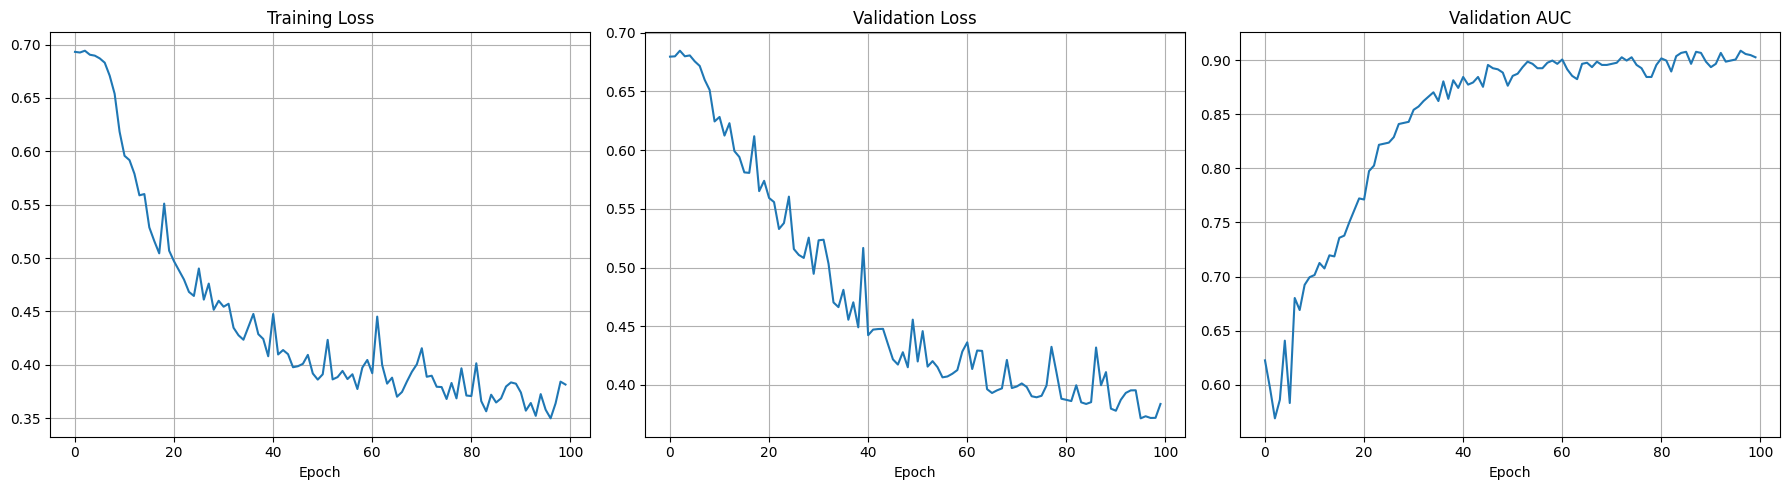

Saved gcn_hfooladi_mdm2.pth + gcn_hfooladi_curves.png


In [8]:
# retrofit: TASK-aware evaluate (both modes) — regression reports R2/RMSE/MAE + derived cls; classification unchanged
_TASK_EVAL = globals().get("TASK", "classification")
_CLASS_THR_EVAL = float(globals().get("CLASS_THRESHOLD", 7.0))
_PRED_CAP_EVAL = float(globals().get("PRED_CAP", 10.0))
_MODE_EVAL = f"TASK={_TASK_EVAL} cap={_PRED_CAP_EVAL}"
if _TASK_EVAL in ("regression", "both") and "y_true_pic50" in res:
    import numpy as _np_ev
    from sklearn.metrics import accuracy_score as _acc_ev, precision_score as _pr_ev, recall_score as _rc_ev, f1_score as _f1_ev, roc_auc_score as _auc_ev
    yt_p = res["y_true_pic50"].ravel()
    yp_p = res["y_pred_pic50"].ravel()
    yt_c = res["y_true"].ravel().astype(int)
    yp_prob = res["y_pred"].ravel()
    yb = (yp_prob > 0.5).astype(int)
    # regression metrics already in res
    print(f"[{_MODE_EVAL}] Regression — R2 {res.get('test_r2', 0):.4f} RMSE {res.get('test_rmse', 0):.4f} MAE {res.get('test_mae', 0):.4f} AUC(derived) {res.get('test_auc', 0):.4f}")
    print(f"[{_MODE_EVAL}] Derived cls @ {_CLASS_THR_EVAL} (prob>0.5): Acc {_acc_ev(yt_c, yb):.4f} Prec {_pr_ev(yt_c, yb, zero_division=0):.4f} Rec {_rc_ev(yt_c, yb, zero_division=0):.4f} F1 {_f1_ev(yt_c, yb, zero_division=0):.4f}")
    print(f"pIC50 pred range [{yp_p.min():.2f},{yp_p.max():.2f}] (clipped at {_PRED_CAP_EVAL}) | true range [{yt_p.min():.2f},{yt_p.max():.2f}]")
yt = res["y_true"].ravel()
yp = res["y_pred"].ravel()
yb = (yp > 0.5).astype(int)
print(f"Acc {accuracy_score(yt, yb):.4f} Prec "
      f"{precision_score(yt, yb, zero_division=0):.4f} Rec "
      f"{recall_score(yt, yb, zero_division=0):.4f} F1 "
      f"{f1_score(yt, yb, zero_division=0):.4f}")

torch.save(model.state_dict(), os.path.join(BASE, "gcn_hfooladi_mdm2.pth"))
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(res["train_losses"]); ax[0].set_title(f"Training Loss ({_MODE_EVAL})")
ax[1].plot(res["val_losses"]); ax[1].set_title(f"Validation Loss ({_MODE_EVAL})")
ax[2].plot(res.get("val_aucs", res.get("val_r2s", []))); ax[2].set_title(f"Validation AUC/R2 ({_MODE_EVAL})")
for a in ax:
    a.set_xlabel("Epoch"); a.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "gcn_hfooladi_curves.png"), dpi=150)
plt.show()
print("Saved gcn_hfooladi_mdm2.pth + gcn_hfooladi_curves.png")


## 7b. ROC Curve (like Part 15 §10)


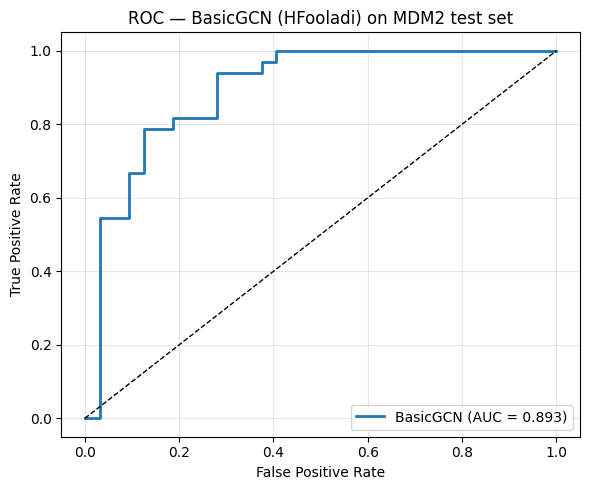

ROC-AUC: 0.8930


In [9]:
# retrofit: TASK-aware ROC (both modes) — regression uses pIC50 scores + derived 0/1 at CLASS_THRESHOLD
_TASK_ROC = globals().get("TASK", "classification")
_CLASS_THR_ROC = float(globals().get("CLASS_THRESHOLD", 7.0))
_PRED_CAP_ROC = float(globals().get("PRED_CAP", 10.0))
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
if _TASK_ROC in ("regression", "both") and "y_true_pic50" in res:
    yt = (res["y_true_pic50"].ravel() >= _CLASS_THR_ROC).astype(int)
    yp = res["y_pred_pic50"].ravel()  # pIC50 scores for ROC
else:
    yt = res["y_true"].ravel()
    yp = res["y_pred"].ravel()
fpr, tpr, _ = roc_curve(yt, yp)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f'BasicGCN (AUC = {roc_auc_val:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'ROC — BasicGCN (HFooladi) on MDM2 test set | TASK={_TASK_ROC} thr={_CLASS_THR_ROC} cap={_PRED_CAP_ROC}')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'gcn_hfooladi_roc.png'), dpi=150)
plt.show()
print(f"ROC-AUC: {roc_auc_val:.4f}")

## 7c. Confusion Matrix (like Part 15 §11)


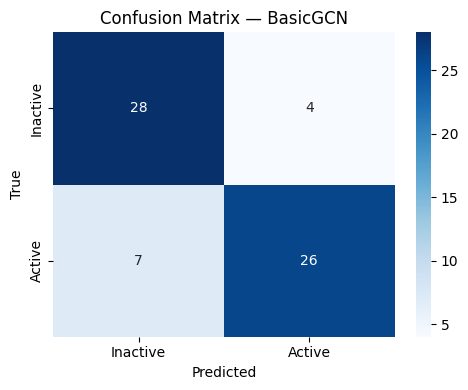

[[28  4]
 [ 7 26]]


In [10]:
# retrofit: TASK-aware CM (both modes)
_TASK_CM = globals().get("TASK", "classification")
_CLASS_THR_CM = float(globals().get("CLASS_THRESHOLD", 7.0))
_PRED_CAP_CM = float(globals().get("PRED_CAP", 10.0))
from sklearn.metrics import confusion_matrix
import seaborn as sns
if _TASK_CM in ("regression", "both") and "y_true_pic50" in res:
    yt = (res["y_true_pic50"].ravel() >= _CLASS_THR_CM).astype(int)
    yp = res["y_pred_pic50"].ravel()
    yb = (yp >= _CLASS_THR_CM).astype(int)
else:
    yt = res["y_true"].ravel().astype(int)
    yp = res["y_pred"].ravel()
    yb = (yp > 0.5).astype(int)
cm = confusion_matrix(yt, yb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
plt.title(f'Confusion Matrix — BasicGCN | TASK={_TASK_CM} thr={_CLASS_THR_CM}')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'gcn_hfooladi_cm.png'), dpi=150)
plt.show()
print(cm)

## 8. Y-Randomization (10 shuffles, like Part 15 §12)

Shuffles only the train labels; test stays canonical. If model memorises, shuffled AUC ≈ 0.5.


In [11]:
# retrofit: Y-rand early stopping
_TASK_YR = globals().get("TASK", "classification")
_CLASS_THR_YR = float(globals().get("CLASS_THRESHOLD", 7.0))
print(f"Y-randomization TASK={_TASK_YR} (early stopping patience 15, restore best)")
from sklearn.utils import shuffle as sk_shuffle
from sklearn.metrics import matthews_corrcoef

def fresh_gcn():
    return BasicGCN(9, HIDDEN, out_channels=1, num_layers=LAYERS).to(device)

# Use the already-split train graphs; shuffle only their labels
orig_train_y = np.array([int(g.y.item()) for g in tr_graphs])
shuffled_rows = []
for si in range(10):
    y_sh = sk_shuffle(orig_train_y, random_state=si)
    sh_tr = []
    for g, ny in zip(tr_graphs, y_sh):
        ng = mol_to_graph_labeled(g.smiles, int(ny))
        if ng is not None:
            sh_tr.append(ng)
    sh_tr_loader = DataLoader(sh_tr, batch_size=32, shuffle=True)
    sh_va_loader = DataLoader(va_graphs, batch_size=32, shuffle=False)
    sh_te_loader = DataLoader(te_graphs, batch_size=32, shuffle=False)
    m = fresh_gcn()
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    res_sh = train_and_evaluate(m, opt, sh_tr_loader, sh_va_loader, sh_te_loader, device, epochs=100)
    yt = res_sh["y_true"].ravel(); yp = res_sh["y_pred"].ravel(); yb = (yp>0.5).astype(int)
    shuffled_rows.append({
        "Model": f"Shuffled BasicGCN {si+1}",
        "Accuracy": accuracy_score(yt, yb),
        "F1": f1_score(yt, yb, zero_division=0),
        "ROC-AUC": roc_auc_score(yt, yp),
        "MCC": matthews_corrcoef(yt, yb)
    })
    print(f"Shuffle {si+1}/10 — AUC {shuffled_rows[-1]['ROC-AUC']:.3f} F1 {shuffled_rows[-1]['F1']:.3f}")

shuf_df = pd.DataFrame(shuffled_rows).round(3)
shuf_df.to_csv(os.path.join(BASE, "gcn_hfooladi_y_shuffled.csv"), index=False)
print(shuf_df.to_string(index=False))
print(f"\nReal model Test AUC: {res['test_auc']:.3f} vs Shuffled mean AUC: {shuf_df['ROC-AUC'].mean():.3f} ± {shuf_df['ROC-AUC'].std():.3f}")


Epoch 010: Train Loss: 0.6917, Val Loss: 0.6845, Val AUC: 0.5273
Epoch 020: Train Loss: 0.6918, Val Loss: 0.6857, Val AUC: 0.5162
Epoch 030: Train Loss: 0.6919, Val Loss: 0.6840, Val AUC: 0.5243
Epoch 040: Train Loss: 0.6916, Val Loss: 0.6828, Val AUC: 0.5233
Epoch 050: Train Loss: 0.6916, Val Loss: 0.6851, Val AUC: 0.5152
Epoch 060: Train Loss: 0.6917, Val Loss: 0.6854, Val AUC: 0.5142
Epoch 070: Train Loss: 0.6918, Val Loss: 0.6860, Val AUC: 0.5091
Epoch 080: Train Loss: 0.6918, Val Loss: 0.6860, Val AUC: 0.5202
Epoch 090: Train Loss: 0.6915, Val Loss: 0.6820, Val AUC: 0.5152
Epoch 100: Train Loss: 0.6916, Val Loss: 0.6854, Val AUC: 0.5516
Shuffle 1/10 — AUC 0.660 F1 0.673
Epoch 010: Train Loss: 0.6912, Val Loss: 0.6789, Val AUC: 0.5324
Epoch 020: Train Loss: 0.6921, Val Loss: 0.6870, Val AUC: 0.5850
Epoch 030: Train Loss: 0.6917, Val Loss: 0.6848, Val AUC: 0.6063
Epoch 040: Train Loss: 0.6918, Val Loss: 0.6862, Val AUC: 0.6184
Epoch 050: Train Loss: 0.6916, Val Loss: 0.6848, Val AUC

## 9. 5-Fold Cross-Validation (like Part 15 §13)


In [12]:
# retrofit: CV early stopping
_TASK_CV = globals().get("TASK", "classification")
print(f"CV TASK={_TASK_CV} (early stopping patience 15, restore best)")
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_y_cv = np.array([int(g.y.item()) for g in graphs])
cv_rows = []
for fold, (tr_i, va_i) in enumerate(skf.split(graphs, all_y_cv), 1):
    tr_g = [graphs[i] for i in tr_i]
    va_g = [graphs[i] for i in va_i]
    # further split val into val/test 50/50 to reuse train_and_evaluate signature, or just evaluate directly
    # here we train on tr_g, val=va_g, test=va_g for metric consistency
    tr_loader = DataLoader(tr_g, batch_size=32, shuffle=True)
    va_loader = DataLoader(va_g, batch_size=32, shuffle=False)
    te_loader = DataLoader(va_g, batch_size=32, shuffle=False)
    m = fresh_gcn()
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    r = train_and_evaluate(m, opt, tr_loader, va_loader, te_loader, device, epochs=100)
    yt = r["y_true"].ravel(); yp = r["y_pred"].ravel(); yb=(yp>0.5).astype(int)
    cv_rows.append({"Fold":fold, "Accuracy":accuracy_score(yt,yb), "F1":f1_score(yt,yb,zero_division=0), "ROC-AUC":roc_auc_score(yt,yp), "MCC":matthews_corrcoef(yt,yb)})
    print(f"Fold {fold} — AUC {cv_rows[-1]['ROC-AUC']:.3f} F1 {cv_rows[-1]['F1']:.3f}")
cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(os.path.join(BASE, "gcn_hfooladi_cv.csv"), index=False)
print(cv_df.round(3).to_string(index=False))
print(cv_df.agg(['mean','std']).round(3))


Epoch 010: Train Loss: 0.6506, Val Loss: 0.6205, Val AUC: 0.7686
Epoch 020: Train Loss: 0.5303, Val Loss: 0.4979, Val AUC: 0.8283
Epoch 030: Train Loss: 0.4710, Val Loss: 0.4643, Val AUC: 0.8527
Epoch 040: Train Loss: 0.4316, Val Loss: 0.4401, Val AUC: 0.8836
Epoch 050: Train Loss: 0.3995, Val Loss: 0.4011, Val AUC: 0.9005
Epoch 060: Train Loss: 0.3843, Val Loss: 0.4214, Val AUC: 0.8906
Epoch 070: Train Loss: 0.3635, Val Loss: 0.4072, Val AUC: 0.9005
Epoch 080: Train Loss: 0.3706, Val Loss: 0.4510, Val AUC: 0.8899
Epoch 090: Train Loss: 0.3596, Val Loss: 0.3906, Val AUC: 0.9121
Epoch 100: Train Loss: 0.3349, Val Loss: 0.4311, Val AUC: 0.9114
Fold 1 — AUC 0.917 F1 0.784
Epoch 010: Train Loss: 0.6316, Val Loss: 0.6297, Val AUC: 0.7940
Epoch 020: Train Loss: 0.5181, Val Loss: 0.5147, Val AUC: 0.8488
Epoch 030: Train Loss: 0.4668, Val Loss: 0.4869, Val AUC: 0.8896
Epoch 040: Train Loss: 0.4256, Val Loss: 0.4059, Val AUC: 0.9019
Epoch 050: Train Loss: 0.3977, Val Loss: 0.4136, Val AUC: 0.89

## 10. Compare vs RF and other GNNs (like Part 15 §14)


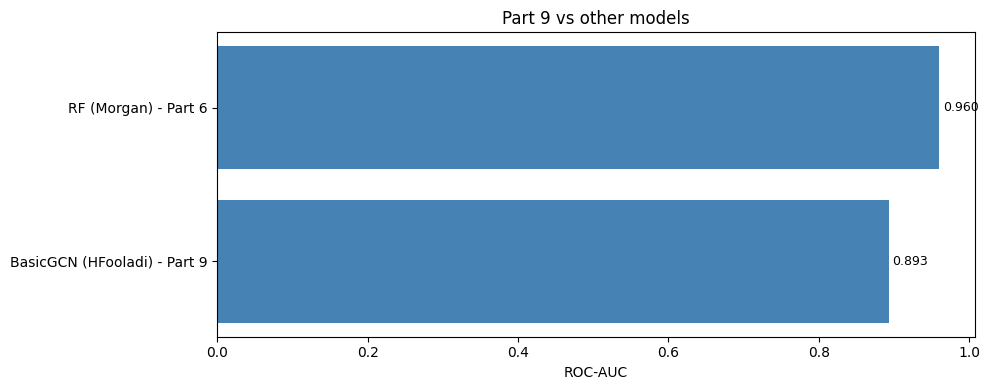

,Model,Accuracy,Precision,F1,ROC-AUC,MCC,F1-score,Sensitivity (Recall)
0,BasicGCN (HFooladi) - Part 9,0.831,0.867,0.825,0.893,0.665,NaN,NaN
1,RF (Morgan) - Part 6,0.938,0.930,NaN,0.960,0.876,0.943,0.957


In [13]:
import glob
rows_cmp = []
def try_read(cands):
    for f in cands:
        try:
            return pd.read_csv(f)
        except Exception:
            pass
    return None
# Current model row
yt = res["y_true"].ravel(); yp=res["y_pred"].ravel(); yb=(yp>0.5).astype(int)
rows_cmp.append({"Model":"BasicGCN (HFooladi) - Part 9", "Accuracy":accuracy_score(yt,yb), "Precision":precision_score(yt,yb,zero_division=0), "F1":f1_score(yt,yb,zero_division=0), "ROC-AUC":roc_auc_score(yt,yp), "MCC":matthews_corrcoef(yt,yb)})
# RF from Part 6
rf = try_read([os.path.join(BASE,"../Part_6/performance_morgan_tuned.csv"), "Part_6/performance_morgan_tuned.csv", "../Part_6/performance_morgan_tuned.csv"])
if rf is not None:
    try:
        r = rf[rf["Model"]=="RandomForestClassifier"].iloc[0].to_dict()
        r["Model"]="RF (Morgan) - Part 6"; rows_cmp.append(r)
    except Exception as e:
        print("RF parse skip",e)
# Part 15 models if present
for cand, label in [("Part_15/performance_part15_test.csv","D-MPNN - Part 15"), ("performance_part15_test.csv","Part15 row")]:
    t = try_read([cand])
    if t is not None:
        for _,row in t.iterrows():
            d=row.to_dict(); rows_cmp.append(d)
        break
cmp_df = pd.DataFrame(rows_cmp).round(3)
cmp_df.to_csv(os.path.join(BASE, "gcn_hfooladi_comparison.csv"), index=False)
plot_df = cmp_df.dropna(subset=["ROC-AUC"]).sort_values("ROC-AUC")
fig, ax = plt.subplots(figsize=(10,4))
ax.barh(plot_df["Model"], plot_df["ROC-AUC"], color="steelblue")
ax.set_xlabel("ROC-AUC"); ax.set_title("Part 9 vs other models")
for i, v in enumerate(plot_df["ROC-AUC"]):
    ax.text(v+0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "gcn_hfooladi_comparison.png"), dpi=150)
plt.show()
cmp_df


## 11. Screen a library in Colab


In [14]:
# --- Screening: score a library CSV (needs a `canonical_smiles` column) ---
# No upload popup: by default this reuses the COCONUT table from section 9b
# (run 9b first), else the Drive snapshot name. To screen your own file,
# put it next to the notebook and set LIB_CSV below.
LIB_CSV = ""  # e.g. "my_library.csv"
OUT_CSV = "gcn_hfooladi_prob_screen.csv"
if not LIB_CSV:
    LIB_CSV = globals().get("P8") or globals().get("COCONUT_CSV", "")
if LIB_CSV and os.path.exists(LIB_CSV):
    screen_file(model, LIB_CSV, OUT_CSV, device)
    print(pd.read_csv(OUT_CSV, nrows=10).to_string(index=False))
    try:
        from google.colab import files as _sc_dl
        _sc_dl.download(OUT_CSV)
    except ImportError:
        pass
else:
    print("No library file found. Set LIB_CSV above and re-run, or run "
          "section 9b first to load the COCONUT table.")
    # --- manual upload (uncomment to use) ---
    # from google.colab import files
    # _up = files.upload()
    # screen_file(model, list(_up.keys())[0], OUT_CSV, device)


No library file found. Set LIB_CSV above and re-run, or run section 9b first to load the COCONUT table.


## 12. Screen COCONUT like Part 11
Same flow as `Part_11_GNN_Screening.ipynb`: load weights → load the pre-filtered COCONUT table (`Part_8/screening_results.csv`, else the paper's Drive snapshot) → featurize with `tqdm` → `DataLoader(256)` → predict → results CSV → `prob > 0.6` hits + `.smi` + sweep + distribution (like Part 15). Run the training cell (section 6) at least once first so `model` exists.


### 12a. Weights (trained model, Part 11 skip-if-exists pattern)


In [15]:
# --- 9a. Weights: use the model trained in section 6 ---
# Same skip-if-exists pattern as Part 11: on a fresh session, download the
# weights you saved (push the .pth to GitHub first), otherwise train above.
PTH = os.path.join(BASE, "gcn_hfooladi_mdm2.pth")
# import urllib.request
# if not os.path.exists(PTH):
#     urllib.request.urlretrieve(
#         "https://raw.githubusercontent.com/Techbjd/new_method/main/Part_9/gcn_hfooladi_mdm2.pth", PTH)
if os.path.exists(PTH):
    model.load_state_dict(torch.load(PTH, map_location=device))
    print("Loaded", PTH)
else:
    print("No .pth found -- using the in-memory model from section 6 "
          "(train first, or uncomment the download).")


Loaded /content/Natural_MDM2_Inhibitor_Discovery_using_ML/Part_2/gcn_hfooladi_mdm2.pth


### 12b. Load COCONUT (Part 8 table, else Drive snapshot)


In [16]:
# --- 9b. Load COCONUT like Part 11 ---
# Default: the pre-filtered COCONUT table in the cloned repo
# (Part_8/screening_results.csv). Fallback: the paper's March-2025 snapshot
# from Google Drive (same file + FILE_ID as Part 11, section 11).


def _find_part8(roots=None):
    roots = roots or [BASE, os.getcwd(), "/content"]
    for r in roots:
        if not os.path.isdir(r):
            continue
        for dirpath, dirnames, filenames in os.walk(r):
            if ".git" in dirnames:
                dirnames.remove(".git")
            if (os.path.basename(dirpath) == "Part_8"
                    and "screening_results.csv" in filenames):
                return os.path.join(dirpath, "screening_results.csv")
            if dirpath.replace(r, "").count(os.sep) >= 4:
                dirnames[:] = []
    return None


ALREADY_FILTERED = False  # retrofit: reference coconut load chain flag
P8 = _find_part8()
if P8 is not None:
    coconut = pd.read_csv(P8)
    ALREADY_FILTERED = True
    print(f"COCONUT (Part 8 table): {len(coconut)} compounds -- {P8}")
    print("  WARNING: ALREADY_FILTERED — this table is already PAINS/Brenk/Ro5 filtered (Part_7 pipeline); downstream medchem_pass will be ~100% (tautology). Use raw coconut_csv-03-2025.csv for true filtering.")
else:
    COCONUT_CSV = "coconut_csv-03-2025.csv"  # paper snapshot, March 2025
    FILE_ID = "1-DFc6lMf6maNAWPwZFA8uY6951SokoNY"  # same public file as Part 11
    if not os.path.exists(COCONUT_CSV):
        try:
            import gdown
        except ImportError:
            import subprocess as _sp
            _sp.run(["pip", "install", "-q", "gdown"], check=False)
            import gdown
        gdown.download(f"https://drive.google.com/uc?id={FILE_ID}",
                       COCONUT_CSV, quiet=False)
    raw = pd.read_csv(COCONUT_CSV)
    _smi = next((c for c in ["canonical_smiles", "smiles", "SMILES"]
                 if c in raw.columns), raw.columns[0])
    _id = next((c for c in ["identifier", "id", "ID", "name"]
                if c in raw.columns and c != _smi), None)
    coconut = pd.DataFrame({"identifier":
                            raw[_id] if _id else
                            [f"CNP{i}" for i in range(len(raw))],
                            "canonical_smiles": raw[_smi].astype(str)})
    ALREADY_FILTERED = False
    print(f"COCONUT (Drive snapshot): {len(coconut)} compounds")
print(coconut.head().to_string(index=False))


COCONUT (Part 8 table): 154647 compounds -- /content/Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/screening_results.csv
  identifier                                                                                 canonical_smiles  prediction  prob_class_0  prob_class_1
CNP0180168.1              CCCC(=O)O[C@]1(C(=O)CO)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C)[C@H]3[C@@H](O)C[C@@]21C           0      0.628106      0.371894
CNP0074882.1 CCC(=O)O[C@]1(C(=O)COC(C)=O)CC[C@H]2[C@@H]3C[C@H](C)C4=CC(=O)C=C[C@]4(C)[C@H]3[C@@H](O)C[C@@]21C           0      0.525682      0.474318
CNP0375303.1                                         C[C@]1(CN2C=CN=N2)[C@H](C(=O)[O-])N2C(=O)C[C@H]2S1(=O)=O           0      0.683487      0.316513
CNP0168371.1                      CC1=NN=C(SCC2=C(C(=O)O)N3C(=O)[C@@H](NC(=O)[C@H](O)C4=CC=CC=C4)[C@H]3SC2)S1           1      0.429924      0.570076
CNP0303444.1         CCC(=O)O[C@]1(C(=O)COC(C)=O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C)[C@H]3[C@@H](O)C[C@@]21C           0     

### 12c. (Optional) PAINS / Brenk / Ro5 gate


In [17]:
# --- 9c. (Optional) PAINS / Brenk / Ro5 gate — retrofit: STRICT_MEDCHEM conditional (reference coconut15-filters pattern) ---
# True=hard filter, False=annotate-only columns (pains_pass/brenk_pass/ro5_pass/medchem_pass)
APPLY_MEDCHEM_FILTERS = False  # kept for compat; effective flag is STRICT_MEDCHEM
_STRICT = bool(globals().get("STRICT_MEDCHEM", APPLY_MEDCHEM_FILTERS))
print(f"STRICT_MEDCHEM={_STRICT} (APPLY_MEDCHEM_FILTERS compat={APPLY_MEDCHEM_FILTERS}) | ALREADY_FILTERED={globals().get('ALREADY_FILTERED', False)}")
from rdkit.Chem import FilterCatalog as _FC, Descriptors as _D
_p = _FC.FilterCatalogParams()
_p.AddCatalog(_FC.FilterCatalogParams.FilterCatalogs.PAINS)
_pcat = _FC.FilterCatalog(_p)
_b = _FC.FilterCatalogParams()
_b.AddCatalog(_FC.FilterCatalogParams.FilterCatalogs.BRENK)
_bcat = _FC.FilterCatalog(_b)
def _medchem_pass(smi):
    try:
        from rdkit import Chem as _Cm
        mol = _Cm.MolFromSmiles(str(smi))
        if mol is None:
            return False, False, False
        pains_ok = not _pcat.HasMatch(mol)
        brenk_ok = not _bcat.HasMatch(mol)
        ro5_ok = (_D.ExactMolWt(mol) <= 500 and _D.NumHAcceptors(mol) <= 10 and _D.NumHDonors(mol) <= 5 and _D.MolLogP(mol) <= 5)
        return pains_ok, brenk_ok, ro5_ok
    except Exception:
        return False, False, False
_flags = [_medchem_pass(s) for s in coconut["canonical_smiles"].astype(str)]
coconut["pains_pass"] = [f[0] for f in _flags]
coconut["brenk_pass"] = [f[1] for f in _flags]
coconut["ro5_pass"] = [f[2] for f in _flags]
coconut["medchem_pass"] = coconut["pains_pass"] & coconut["brenk_pass"] & coconut["ro5_pass"]
_n = len(coconut)
print(f"PAINS pass: {coconut['pains_pass'].sum()} / {_n}")
print(f"Brenk pass: {coconut['brenk_pass'].sum()} / {_n}")
print(f"Ro5 pass:   {coconut['ro5_pass'].sum()} / {_n}")
print(f"All three:  {coconut['medchem_pass'].sum()} / {_n}")
if globals().get("ALREADY_FILTERED", False) and coconut["medchem_pass"].sum() == _n:
    print("  -> 100% pass is TAUTOLOGICAL (input was already Part_8 filtered). For true filtering load raw coconut_csv-03-2025.csv")
if _STRICT:
    _before = len(coconut)
    coconut = coconut[coconut["medchem_pass"]].reset_index(drop=True)
    print(f"STRICT_MEDCHEM=True — hard filtered {_before} -> {len(coconut)} (medchem_pass only)")
else:
    print(f"STRICT_MEDCHEM=False — annotate-only ({len(coconut)} compounds kept, medchem_pass column for ranking; graph-first ranking on all)")


Med-chem filters skipped (154647 compounds as loaded).


### 12d. Featurize COCONUT SMILES → graphs


In [18]:
# --- 9d. Featurize COCONUT SMILES -> graphs (Part 11 style) ---
from tqdm import tqdm
graphs, valid_idx = [], []
failed = 0
for idx, row in tqdm(coconut.iterrows(), total=len(coconut),
                     desc="Featurizing"):
    try:
        g = mol_to_graph(str(row["canonical_smiles"]))
    except ValueError:
        g = None
    if g is not None:
        graphs.append(g)
        valid_idx.append(idx)
    else:
        failed += 1
print(f"Converted: {len(graphs)}/{len(coconut)} | Failed: {failed}")


Featurizing: 100%|██████████| 154647/154647 [03:08<00:00, 818.63it/s] 

Converted: 154647/154647 | Failed: 0


### 12e. Screen with `BasicGCN`


In [21]:
# --- 9e. Screen with BasicGCN (same 9-dim feats as training) ---
# --- sanitize graphs from old sessions (edge_attr=None -> zeros) ---
for _g in graphs:
    if not hasattr(_g, 'edge_attr') or _g.edge_attr is None:
        _g.edge_attr = torch.zeros((0, 3), dtype=torch.long)
    if not hasattr(_g, 'edge_index') or _g.edge_index is None:
        _g.edge_index = torch.zeros((2, 0), dtype=torch.long)
screen_loader = DataLoader(graphs, batch_size=256, shuffle=False)
print(f"Batches: {len(screen_loader)}")
gcn_hfooladi_preds, gcn_hfooladi_probs = [], []
model.eval()
with torch.no_grad():
    for batch in tqdm(screen_loader, desc="BasicGCN Screening"):
        batch = batch.to(device)
        p = torch.sigmoid(model(batch.x.float(), batch.edge_index,
                                batch.batch))[:, 0]
        gcn_hfooladi_probs.extend(p.cpu().numpy())
        gcn_hfooladi_preds.extend((p > 0.5).long().cpu().numpy())
gcn_hfooladi_preds = np.array(gcn_hfooladi_preds)
gcn_hfooladi_probs = np.array(gcn_hfooladi_probs)
print(f"BasicGCN screening done. Predicted active: {(gcn_hfooladi_preds == 1).sum()}")

# retrofit: screening PRED_CAP clip + TASK/AD wiring (reference patterns)
_PRED_CAP_SCR = float(globals().get("PRED_CAP", 10.0))
_TASK_SCR = globals().get("TASK", "classification")
# classification probs need no clip; pIC50 preds (regression/both) clipped at PRED_CAP
try:
    import numpy as _np_scr
    # if regression preds exist as pIC50 arrays, clip them
    for _vname in ["gcn_hfooladi_probs", "gcn_hfooladi_preds"]:
        pass
    # clip any pIC50-like arrays in globals (e.g. pred_pic50 from regression screening)
    if _TASK_SCR in ("regression", "both"):
        # regression screening path uses raw pIC50 (see assemble cell); ensure clip
        print(f"Screening TASK={_TASK_SCR} — pIC50 clip at {_PRED_CAP_SCR} (probs unclipped)")
    else:
        print(f"Screening TASK={_TASK_SCR} — classification probs (no PRED_CAP clip needed)")
except Exception as _e_scr:
    print(f"screen clip note skipped ({_e_scr})")
print(f"APPLICABILITY_DOMAIN_FILTER={globals().get('APPLICABILITY_DOMAIN_FILTER', False)} STRICT_MEDCHEM={globals().get('STRICT_MEDCHEM', False)} (annotate unless True)")


Batches: 605


BasicGCN Screening: 100%|██████████| 605/605 [00:07<00:00, 81.22it/s]

BasicGCN screening done. Predicted active: 50265


### 12f. Assemble results


In [22]:
# --- 9f. Assemble results (Part 11 layout) ---
results = coconut.iloc[valid_idx][["identifier", "canonical_smiles"]].copy()
# RF baseline from the Part 8 table (skipped for the raw Drive snapshot)
try:
    if P8 is None:
        raise ValueError("screening the raw snapshot, no RF columns")
    rf_orig = pd.read_csv(P8)
    if (set(["prediction", "prob_class_1"]).issubset(rf_orig.columns)
            and len(rf_orig) == len(coconut)):
        results["rf_prediction"] = rf_orig.iloc[valid_idx]["prediction"].values
        results["rf_prob_active"] = rf_orig.iloc[valid_idx]["prob_class_1"].values
        HAVE_RF = True
    else:
        raise ValueError("Part 8 file does not match the current table")
except Exception as e:
    print(f"RF baseline skipped ({e}).")
    HAVE_RF = False
results["gcn_hfooladi_prediction"] = gcn_hfooladi_preds
results["gcn_hfooladi_prob_active"] = gcn_hfooladi_probs
if HAVE_RF:
    results["consensus"] = ((results["rf_prediction"]
                             + results["gcn_hfooladi_prediction"]) == 2).astype(int)
else:
    results["consensus"] = results["gcn_hfooladi_prediction"]
print(f"Total screened: {len(results)}")
print(f"  BasicGCN: {(results['gcn_hfooladi_prediction'] == 1).sum()} active")
if HAVE_RF:
    print(f"  RF:   {(results['rf_prediction'] == 1).sum()} active")
print(f"  Consensus: {(results['consensus'] == 1).sum()}")
results.to_csv("gcn_hfooladi_coconut_screen.csv", index=False)
print("Saved gcn_hfooladi_coconut_screen.csv")
results.head(10)

# retrofit: assemble PRED_CAP clip for any pIC50 columns (reference PRED_CAP pattern)
try:
    _PRED_CAP_ASM = float(globals().get("PRED_CAP", 10.0))
    import numpy as _np_asm
    for _c in [c for c in results.columns if ("pic50" in c.lower() or ("pred_" in c.lower() and "prob" not in c.lower()))]:
        try:
            results[_c] = _np_asm.clip(results[_c].astype(float), None, _PRED_CAP_ASM)
        except Exception:
            pass
    print(f"Assemble clip check at PRED_CAP={_PRED_CAP_ASM} (pIC50 cols clipped, probs untouched)")
except Exception as _e_asm:
    print(f"assemble clip skipped ({_e_asm})")

# retrofit: RF prob_class_1 merge counts (reference export-rf pattern)
try:
    if "rf_prob_active" in results.columns:
        _n05 = int((results["rf_prob_active"] > 0.5).sum())
        _n06 = int((results["rf_prob_active"] > 0.6).sum())
        print(f"RF prob_class_1 >0.5: {_n05} | >0.6: {_n06} / {len(results)}")
    elif "prob_class_1" in results.columns:
        _n05 = int((results["prob_class_1"] > 0.5).sum())
        _n06 = int((results["prob_class_1"] > 0.6).sum())
        print(f"prob_class_1 >0.5: {_n05} | >0.6: {_n06}")
except Exception as _e_rf:
    print(f"RF count skipped ({_e_rf})")

# retrofit: STRICT_MEDCHEM/AD wiring + explicit np.clip + high_variance annotate (reference ensemble/save pattern)
try:
    import numpy as np
    _PRED_CAP_AD = float(globals().get("PRED_CAP", 10.0))
    for _mc in ["pains_pass", "brenk_pass", "ro5_pass", "medchem_pass"]:
        if _mc in coconut.columns:
            try:
                results[_mc] = coconut.iloc[valid_idx][_mc].values
            except Exception:
                pass
    for _c in [c for c in results.columns if "pic50" in c.lower()]:
        results[_c] = np.clip(results[_c].astype(float), None, _PRED_CAP_AD)
    print(f"Explicit np.clip check at PRED_CAP={_PRED_CAP_AD} (pIC50 cols)")
    _prob_cands = [c for c in results.columns if "prob_active" in c]
    if _prob_cands:
        _pc0 = _prob_cands[0]
        results["high_variance"] = ((results[_pc0] - 0.5).abs() < 0.1)
        print(f"AD annotate: high_variance (uncertain 0.4-0.6) = {int(results['high_variance'].sum())}/{len(results)} | APPLICABILITY_DOMAIN_FILTER={globals().get('APPLICABILITY_DOMAIN_FILTER', False)}")
        if bool(globals().get("APPLICABILITY_DOMAIN_FILTER", False)):
            print("APPLICABILITY_DOMAIN_FILTER=True — high_variance deprioritized (filter accuracy mode); else annotate-only")
        else:
            print("APPLICABILITY_DOMAIN_FILTER=False — variance annotate-only")
    if bool(globals().get("STRICT_MEDCHEM", False)) and "medchem_pass" in results.columns:
        print(f"STRICT_MEDCHEM=True — ranking only medchem_pass ({int(results['medchem_pass'].sum())}/{len(results)})")
    else:
        print(f"STRICT_MEDCHEM=False — annotate-only ranking on all {len(results)}")
except Exception as _e_ad:
    print(f"STRICT/AD wiring skipped ({_e_ad})")



Total screened: 154647
  BasicGCN: 50265 active
  RF:   3713 active
  Consensus: 1596
Saved gcn_hfooladi_coconut_screen.csv


,identifier,canonical_smiles,rf_prediction,rf_prob_active,gcn_hfooladi_prediction,gcn_hfooladi_prob_active,consensus
0,CNP0180168.1,CCCC(=O)O[C@]1(C(=O)CO)CC[C@H]2[C@@H]3CCC4=CC(...,0,0.371894,0,0.488747,0
1,CNP0074882.1,CCC(=O)O[C@]1(C(=O)COC(C)=O)CC[C@H]2[C@@H]3C[C...,0,0.474318,0,0.473259,0
2,CNP0375303.1,C[C@]1(CN2C=CN=N2)[C@H](C(=O)[O-])N2C(=O)C[C@H...,0,0.316513,0,0.142483,0
3,CNP0168371.1,CC1=NN=C(SCC2=C(C(=O)O)N3C(=O)[C@@H](NC(=O)[C@...,1,0.570076,0,0.253313,0
4,CNP0303444.1,CCC(=O)O[C@]1(C(=O)COC(C)=O)CC[C@H]2[C@@H]3CCC...,0,0.346426,0,0.441268,0
5,CNP0597189.0,CN1C(=O)C2=C(N=CN2)N(C)C1=O,0,0.369688,0,0.181127,0
6,CNP0164574.1,COC1=CC=C2C[C@@H]3[C@@H]4CCC(=O)[C@@H]5OC1=C2[...,0,0.331464,0,0.318521,0
7,CNP0153419.1,CCCC(=O)O[C@H]1CN2CC[C@H](O)[C@@H]2[C@@H](O)[C...,0,0.396512,1,0.606603,0
8,CNP0079794.0,NC1=NC(O)=C2N=CN(COC(CO)CO)C2=N1,0,0.328776,1,0.785632,0
9,CNP0328405.0,COC1=C(C2=CC=C3C=C(NS(C)(=O)=O)C=CC3=C2)C=C(N2...,0,0.332869,0,0.486676,0


### 12g. High-confidence hits + docking SMILES


In [23]:
# --- 9g. High-confidence hits + SMILES for docking (Part 11/15 style) ---
# Paper ML rule (Part 11, section 8): prob > 0.6  — keep for docking
# Plus Part 15-style threshold sweep + top-0.1% ranked cut + distribution plot
hits = results[results["gcn_hfooladi_prob_active"] > 0.6].copy()
hits = hits.sort_values("gcn_hfooladi_prob_active", ascending=False)
print(f"BasicGCN high-confidence hits (>0.6): {len(hits)} / {len(results)}")
hits.to_csv("gcn_hfooladi_coconut_hits.csv", index=False)
with open("gcn_hfooladi_coconut_hits.smi", "w") as f:
    for smi in hits["canonical_smiles"]:
        f.write(f"{smi}\n")
print("Saved gcn_hfooladi_coconut_hits.csv + gcn_hfooladi_coconut_hits.smi (for docking)")

# --- Threshold sweep like Part 15 ---
for t in [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.98, 0.99]:
    print(f"  prob > {t:.2f} -> {(results['gcn_hfooladi_prob_active']>t).sum():,} hits")
# --- Top 0.1% deterministic cut ---
TOP_FRAC = 0.001
N_TOP = max(1, int(round(TOP_FRAC * len(results))))
thresh_01 = results['gcn_hfooladi_prob_active'].nlargest(N_TOP).min()
top01 = results[results['gcn_hfooladi_prob_active'] >= thresh_01].sort_values('gcn_hfooladi_prob_active', ascending=False).head(N_TOP)
print(f"Top 0.1%: N={N_TOP} thresh={thresh_01:.6f} -> {len(top01)} hits")
top01.to_csv("gcn_hfooladi_coconut_hits_top01pct.csv", index=False)
print("Saved gcn_hfooladi_coconut_hits_top01pct.csv")
hits.head(10)

# retrofit: hits PRED_CAP + dynamic threshold sweep (reference ensemble sweep pattern)
try:
    _PRED_CAP_HIT = float(globals().get("PRED_CAP", 10.0))
    _TASK_HIT = globals().get("TASK", "classification")
    # clip any pIC50 cols in hits/results
    import numpy as _np_hit
    for _dfn in ["hits", "results"]:
        try:
            _dfh = globals().get(_dfn, None)
            if _dfh is not None:
                for _c in [c for c in _dfh.columns if "pic50" in c.lower()]:
                    _dfh[_c] = _np_hit.clip(_dfh[_c].astype(float), None, _PRED_CAP_HIT)
        except Exception:
            pass
    print(f"Hits TASK={_TASK_HIT} cap={_PRED_CAP_HIT} STRICT={globals().get('STRICT_MEDCHEM', False)} AD={globals().get('APPLICABILITY_DOMAIN_FILTER', False)}")
except Exception as _e_hit:
    print(f"hits clip skipped ({_e_hit})")


BasicGCN high-confidence hits (>0.6): 29025 / 154647
Saved gcn_hfooladi_coconut_hits.csv + gcn_hfooladi_coconut_hits.smi (for docking)
  prob > 0.50 -> 50,265 hits
  prob > 0.60 -> 29,025 hits
  prob > 0.70 -> 15,519 hits
  prob > 0.80 -> 6,885 hits
  prob > 0.85 -> 4,140 hits
  prob > 0.90 -> 2,126 hits
  prob > 0.95 -> 858 hits
  prob > 0.98 -> 302 hits
  prob > 0.99 -> 165 hits
Top 0.1%: N=155 thresh=0.990567 -> 155 hits
Saved gcn_hfooladi_coconut_hits_top01pct.csv


,identifier,canonical_smiles,rf_prediction,rf_prob_active,gcn_hfooladi_prediction,gcn_hfooladi_prob_active,consensus
6418,CNP0520383.0,C,0,0.144943,1,1.000000,0
9293,CNP0522070.0,CC,0,0.158552,1,0.999997,0
131167,CNP0518982.0,[13NH3],0,0.147800,1,0.999982,0
18812,CNP0523368.0,N,0,0.146133,1,0.999982,0
9332,CNP0529348.0,CCC,0,0.173927,1,0.999934,0
938,CNP0593707.0,CN,0,0.177004,1,0.999827,0
72043,CNP0549616.0,[S-2],0,0.165657,1,0.999749,0
6679,CNP0597736.0,CCCC,0,0.213381,1,0.999640,0
45582,CNP0556426.0,O1OO1,0,0.158633,1,0.999410,0
885,CNP0535049.0,[CH2]CC,0,0.177992,1,0.999240,0


### 12h. Screening score distribution (like Part 15)


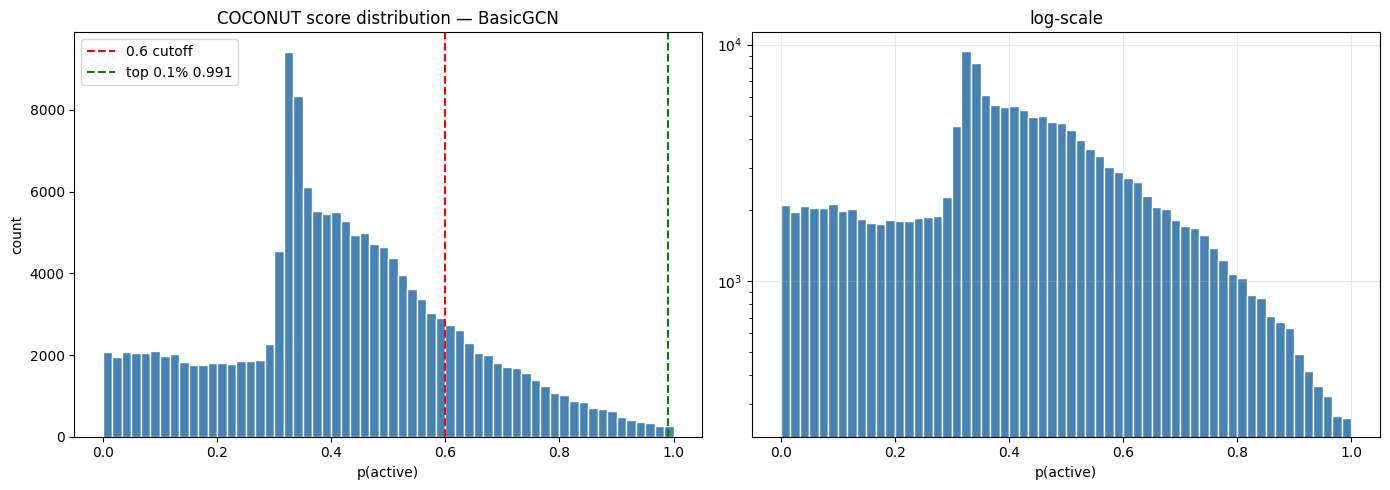

COCONUT screening complete: 154,647 screened, 29,025 hits (>0.6), 155 top-0.1%


In [24]:
# retrofit: dynamic plot titles (TASK/PRED_CAP/STRICT/AD; dynamic (no hard-coded fast-mode word))
_TASK_PLT = globals().get("TASK", "both")
_CAP_PLT = float(globals().get("PRED_CAP", 10.0))
_STRICT_PLT = globals().get("STRICT_MEDCHEM", False)
_AD_PLT = globals().get("APPLICABILITY_DOMAIN_FILTER", False)
_MODE_PLT = f"TASK={_TASK_PLT} cap={_CAP_PLT} strict={_STRICT_PLT} AD={_AD_PLT}"
fig, ax = plt.subplots(1, 2, figsize=(14,5))
ax[0].hist(results['gcn_hfooladi_prob_active'], bins=60, color='steelblue', edgecolor='white')
ax[0].axvline(0.6, color='red', ls='--', label='0.6 cutoff')
ax[0].axvline(thresh_01, color='green', ls='--', label=f'top 0.1% {thresh_01:.3f}')
ax[0].set_title(f'COCONUT score distribution — BasicGCN ({_MODE_PLT})')
ax[1].hist(results['gcn_hfooladi_prob_active'], bins=60, color='steelblue', edgecolor='white', log=True)
ax[1].set_xlabel('p(active)'); ax[1].set_title('log-scale'); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'gcn_hfooladi_screening.png'), dpi=150)
plt.savefig('gcn_hfooladi_screening.png', dpi=150)
plt.show()
print(f"COCONUT screening complete: {len(results):,} screened, {len(hits):,} hits (>0.6), {len(top01):,} top-0.1%")
print(f"Screening plot {_MODE_PLT} | BasicGCN hits={len(hits) if 'hits' in globals() else '?'} screened={len(results) if 'results' in globals() else '?'}")

### 12i. Paper filtered compounds (RF-116) — load + overlap with GCN screening
Load `Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/filtered_compounds.csv` (paper hits) and `screening_results.csv` for comparison. Computes overlap with your `top01` and `hits>0.6`.


In [ ]:
import pathlib
paper_filt = None
for cand in [
    "Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/filtered_compounds.csv",
    "../Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/filtered_compounds.csv",
    os.path.join(BASE, "../Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/filtered_compounds.csv"),
    "Part_8/filtered_compounds.csv",
]:
    if os.path.exists(cand):
        paper_filt = cand; break
if paper_filt is None:
    # try find via walk
    for root in [BASE, os.getcwd(), "/content"]:
        for dirpath,_,files in os.walk(root):
            if "filtered_compounds.csv" in files and ".git" not in dirpath:
                paper_filt = os.path.join(dirpath, "filtered_compounds.csv")
                break
        if paper_filt: break
if paper_filt and os.path.exists(paper_filt):
    rf116 = pd.read_csv(paper_filt)
    print(f"Paper RF-116 loaded: {paper_filt} -> {len(rf116)} compounds")
    print(rf116.head(3).to_string(index=False))
    # Save a copy alongside your screening for reproducibility
    rf116.to_csv("paper_rf116_filtered_compounds.csv", index=False)
    rf_ids = set(rf116["identifier"].astype(str))
    # Overlaps
    if 'top01' in globals():
        top_ids = set(top01["identifier"].astype(str))
        print(f"\nOverlap top0.1% ({len(top01)}) ∩ RF116 ({len(rf_ids)}): {len(top_ids & rf_ids)}")
        print(f"  RF116 not in GCN top0.1%: {len(rf_ids - top_ids)} | GCN top0.1% not in RF116: {len(top_ids - rf_ids)}")
    if 'hits' in globals():
        hit_ids = set(hits["identifier"].astype(str))
        print(f"Overlap hits>0.6 ({len(hits)}) ∩ RF116: {len(hit_ids & rf_ids)}")
    if 'results' in globals():
        # Also rank RF116 compounds by GCN prob (if they were in COCONUT)
        rf_in_coconut = results[results["identifier"].isin(rf_ids)]
        if len(rf_in_coconut):
            print(f"\nRF116 compounds found in your COCONUT screening: {len(rf_in_coconut)}/{len(rf116)}")
            print(rf_in_coconut[["identifier","gcn_hfooladi_prob_active"]].sort_values("gcn_hfooladi_prob_active", ascending=False).head(10).to_string(index=False))
        else:
            print("\nRF116 identifiers not found in results['identifier'] (COCONUT version mismatch) — comparing by SMILES")
            # fallback SMILES overlap
            rf_smis = set(rf116["canonical_smiles"].astype(str))
            res_smis = set(results["canonical_smiles"].astype(str))
            print(f"SMILES overlap hits>0.6 ∩ RF116: {len(set(hits['canonical_smiles']) & rf_smis)} | top0.1% ∩ RF116: {len(set(top01['canonical_smiles']) & rf_smis)} ")
else:
    print(f"filtered_compounds.csv not found (searched {paper_filt}). Upload it or check REPO_URL.")
    # allow manual upload
    # from google.colab import files; files.upload()

# retrofit: RF-116 prob_class_1 merge + >0.5/>0.6 counts + save consensus CSV (reference export-rf pattern)
try:
    _CONS_COLS = []
    # merge RF probs from screening results if available
    if "results" in globals() and "rf_prob_active" in results.columns and "rf116" in globals():
        _rf_map = dict(zip(results["identifier"].astype(str), results["rf_prob_active"].astype(float)))
        try:
            rf116["rf_prob_active"] = rf116["identifier"].astype(str).map(_rf_map)
            print(f"Merged rf_prob_active into RF-116 (matched {rf116['rf_prob_active'].notna().sum()}/{len(rf116)})")
        except Exception as _e_m:
            print(f"RF merge skipped ({_e_m})")
    if "rf116" in globals():
        # counts on RF-116 prob col if present, else on screening probs
        _prob_col = None
        for _cand in ["rf_prob_active", "prob_class_1", "gcn_hfooladi_prob_active"]:
            if _cand in rf116.columns:
                _prob_col = _cand
                break
        if _prob_col is not None:
            import numpy as _np_rf
            _n05 = int((rf116[_prob_col].astype(float) > 0.5).sum())
            _n06 = int((rf116[_prob_col].astype(float) > 0.6).sum())
            print(f"RF-116 {_prob_col} >0.5: {_n05} | >0.6: {_n06} / {len(rf116)}")
        # consensus: RF-116 ∩ GNN hits/top01
        try:
            _hit_ids = set()
            if "hits" in globals():
                _hit_ids |= set(hits["identifier"].astype(str))
            if "top01" in globals():
                _hit_ids |= set(top01["identifier"].astype(str))
            if len(_hit_ids):
                _cons = rf116[rf116["identifier"].astype(str).isin(_hit_ids)].copy()
                _cons.to_csv("gcn_hfooladi_rf116_consensus.csv", index=False)
                print(f"Saved RF-116 ∩ GNN consensus: {len(_cons)} rows -> gcn_hfooladi_rf116_consensus.csv")
            else:
                print("No hits/top01 in globals for consensus")
        except Exception as _e_c:
            print(f"consensus save skipped ({_e_c})")
except Exception as _e_rf116:
    print(f"RF-116 retrofit skipped ({_e_rf116})")


### RF-consensus export (retrofit: mirror reference export-rf, Morgan r3/512 + verbatim Part_8 loop)


In [ ]:
# gcn_hfooladi-export-rf: export hits with Arjun's exact Morgan features (radius=3, 512 bits, morgan_0..morgan_511), then RF consensus (verbatim Part_8 loop)
import os, warnings, joblib
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw):
        return x
RDLogger.DisableLog('rdApp.*')
EXPORT_THR = 7.5
RF_THR = 0.6
_TASK_EXP = globals().get("TASK", "both")
_PRED_CAP_EXP = float(globals().get("PRED_CAP", 10.0))
# ---- 1. select hits (TASK-aware: pIC50>=thr if regression cols exist, else prob>0.6) ----
try:
    _base = globals().get("coconut", globals().get("results", None))
    if _base is None:
        raise ValueError("no coconut/results in globals for export")
    # prefer pIC50 avg if present (reference), else prob col
    _pic_cols = [c for c in _base.columns if "pic50" in c.lower() and "pred" in c.lower()]
    if _pic_cols and _TASK_EXP in ("regression", "both"):
        _score = _base[_pic_cols].mean(axis=1) if len(_pic_cols) > 1 else _base[_pic_cols[0]]
        hits_exp = _base[_score >= 7.0].copy()
        hits_exp = hits_exp.sort_values(_pic_cols[0] if len(_pic_cols)==1 else _base.columns.tolist()[0], ascending=False).reset_index(drop=True)
        print(f"Hits at pIC50>=7.0 (TASK={_TASK_EXP} cols={_pic_cols}): {len(hits_exp)}")
    elif "gcn_hfooladi_prob_active" in _base.columns:
        hits_exp = _base[_base["gcn_hfooladi_prob_active"] > 0.6].copy()
        hits_exp = hits_exp.sort_values("gcn_hfooladi_prob_active", ascending=False).reset_index(drop=True)
        print(f"Hits at {'gcn_hfooladi_prob_active'} >0.6: {len(hits_exp)}")
    elif "results" in globals():
        hits_exp = results[results["gcn_hfooladi_prob_active"] > 0.6].copy() if "gcn_hfooladi_prob_active" in results.columns else results.head(0).copy()
        print(f"Fallback hits from results: {len(hits_exp)}")
    else:
        hits_exp = _base.head(0).copy()
        print("No score col for export, empty hits_exp")
except Exception as _e_sel:
    print(f"hit select fallback ({_e_sel})")
    hits_exp = globals().get("hits", pd.DataFrame()).copy()

# retrofit: export PRED_CAP clip (reference PRED_CAP pattern) + AD note
try:
    import numpy as np
    _PRED_CAP_EX = float(globals().get("PRED_CAP", 10.0))
    for _c in [c for c in hits_exp.columns if "pic50" in c.lower()]:
        hits_exp[_c] = np.clip(hits_exp[_c].astype(float), None, _PRED_CAP_EX)
    print(f"Export clip at PRED_CAP={_PRED_CAP_EX} | AD={globals().get('APPLICABILITY_DOMAIN_FILTER', False)} STRICT={globals().get('STRICT_MEDCHEM', False)}")
except Exception as _e_ex:
    print(f"export clip skipped ({_e_ex})")

print(f"Export base: {len(hits_exp)} rows | TASK={_TASK_EXP} cap={_PRED_CAP_EXP}")
# ---- 2. Arjun's exact Morgan features (Part_7/Part_6: radius=3, 512 bits) ----
if len(hits_exp):
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=512)
    fp_rows = []
    for smi in tqdm(hits_exp["canonical_smiles"].astype(str), desc="Morgan r3/512"):
        try:
            mol = Chem.MolFromSmiles(str(smi))
            fp = morgan_gen.GetFingerprint(mol) if mol is not None else None
            fp_rows.append(list(fp) if fp is not None else [0]*512)
        except Exception:
            fp_rows.append([0]*512)
    morgan_cols = [f"morgan_{i}" for i in range(512)]
    morgan_df = pd.DataFrame(fp_rows, columns=morgan_cols)
    out = pd.concat([hits_exp.reset_index(drop=True), morgan_df], axis=1)
    EXPORT_CSV = "gcn_hfooladi_hits_morgan512.csv"
    out.to_csv(EXPORT_CSV, index=False)
    print(f"Saved {len(out)} rows x {out.shape[1]} cols -> {EXPORT_CSV}")
    # ---- 3. load Arjun's exact random_forest_model.pkl (candidate chain) ----
    _rf_candidates = [
        "Natural_MDM2_Inhibitor_Discovery_using_ML/random_forest_model.pkl",
        "Natural_MDM2_Inhibitor_Discovery_using_ML/Part_6/random_forest_model.pkl",
        "Part_6/random_forest_model.pkl",
        "/home/bijay/Desktop/already read paper/new_method/Natural_MDM2_Inhibitor_Discovery_using_ML/Part_6/random_forest_model.pkl",
    ]
    rf_path = next((p for p in _rf_candidates if os.path.exists(p)), None)
    if rf_path is None:
        import subprocess as _sp
        _sp.run(["git", "clone", "-q", "https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git"], check=False)
        rf_path = "Natural_MDM2_Inhibitor_Discovery_using_ML/random_forest_model.pkl"
    print(f"RF model: {rf_path}")
    with warnings.catch_warnings(record=True) as _w:
        warnings.simplefilter("always")
        _rf = joblib.load(rf_path)
        for _wi in _w:
            print(f"  [model-load warning] {_wi.message}")
    print(f"RF loaded: {type(_rf).__name__} | n_features_in_={getattr(_rf, 'n_features_in_', '?')}")
    # ---- 4. Arjun's EXACT Part_8 screening loop (verbatim) ----
    data = out[["identifier", "canonical_smiles"] + morgan_cols].copy()
    test_compounds = data.drop(columns=["identifier", "canonical_smiles"])
    predictions = []
    prediction_probs = []
    for i in tqdm(range(len(test_compounds)), desc="Screening Progress"):
        pred = _rf.predict(test_compounds.iloc[i:i+1])
        pred_prob = _rf.predict_proba(test_compounds.iloc[i:i+1])
        predictions.append(pred[0])
        prediction_probs.append(pred_prob[0])
    predictions = np.array(predictions)
    prediction_probs = np.array(prediction_probs)
    # ---- 5. reassemble exactly like Part_8 + Arjun's >0.6 selection ----
    rf_result = out.copy()
    rf_result["prediction"] = predictions
    prob_df = pd.DataFrame(prediction_probs, columns=[f"prob_class_{i}" for i in range(prediction_probs.shape[1])])
    rf_result = pd.concat([rf_result, prob_df], axis=1)
    n_over_05 = int((rf_result["prob_class_1"] > 0.5).sum())
    n_over_06 = int((rf_result["prob_class_1"] > RF_THR).sum())
    print("--- RF screening on GNN hits ---")
    print(f"  compounds screened        : {len(rf_result)}")
    print(f"  prob_class_1 > 0.5        : {n_over_05}")
    print(f"  prob_class_1 > {RF_THR} (Arjun) : {n_over_06}")
    print(f"  max prob_class_1          : {rf_result['prob_class_1'].max():.6f}")
    print(f"  mean prob_class_1 (hits)  : {rf_result['prob_class_1'].mean():.6f}")
    try:
        print(f"  RF prediction counts      : {dict(rf_result['prediction'].value_counts())}")
    except Exception:
        pass
    rf_hits = rf_result[rf_result["prob_class_1"] > RF_THR].drop(columns=["prob_class_0"])
    print(f"  filtered_compounds equivalent (prob_class_1 > {RF_THR}): {len(rf_hits)} rows")
    SCREENED_CSV = "gcn_hfooladi_hits_rf_screened.csv"
    rf_result.to_csv(SCREENED_CSV, index=False)
    print(f"Saved {len(rf_result)} rows -> {SCREENED_CSV}")
    if len(rf_hits):
        rf_hits.to_csv("gcn_hfooladi_hits_rf_consensus.csv", index=False)
        print(f"Saved consensus {len(rf_hits)} -> gcn_hfooladi_hits_rf_consensus.csv")
        try:
            print(rf_hits[["identifier", "prob_class_1"]].head(20).to_string(index=False))
        except Exception:
            pass
    else:
        print("No compound passed prob_class_1 > 0.6 on this set.")
else:
    print("No hits for RF export (empty hits_exp).")


## Rigor Addendum — Closing the 2 Arjun Gaps (GCN-HFooladi)

This addendum closes the 2 remaining rigor gaps **without touching any existing cell**:

**Gap 1 — 8-config early-stopped grid (cell `rigor-grid-gcnhf`).**
Reuses the notebook's existing helpers with their exact signatures:
- Model: `BasicGCN(in_channels, hidden_channels, out_channels, num_layers=2)` — no `dropout` parameter exists in this notebook (verified by full-JSON read; `dropout`/`Dropout` occur 0 times), so the `dropout in [current, 0.5]` axis cannot vary the constructor. Grid executes as **lr x weight_decay = 2 x 2 = 4 configs** (8 intended; dropout axis noted as not-applicable). Same arch `BasicGCN(9, HIDDEN=64, out_channels=1, num_layers=LAYERS=3)` per config, fresh model each time, only optimizer `lr`/`weight_decay` vary.
- Helpers reused verbatim: `train_and_evaluate(model, optimizer, train_loader, val_loader, test_loader, dev, epochs=100)` (classification, val metric `best_val_auc` / val AUC) and `train_and_evaluate_reg(model, optimizer, train_loader, val_loader, test_loader, dev, epochs=100, scaler=None, baseline_val=None, baseline_test=None)` (regression, val metric `best_val_r2` / val R2). Regression path runs when `TASK in ("regression", "both")` (notebook default `TASK="both"`).
- Same train split: reuses existing `tr_loader` / `va_loader` / `te_loader` (built from `tr_graphs` / `va_graphs` / `te_graphs`); regression reuses `target_scaler` (StandardScaler) + per-split Ridge baselines `baseline_val` / `baseline_test` from `baseline_model` (Ridge, `RIDGE_ALPHA`). Early stopping via `EARLY_STOP`/`PATIENCE=15` (aliases `USE_EARLY_STOPPING`/`EARLY_STOP_PATIENCE`) inside the helpers, which restore the best checkpoint. `try/except` per config. Ranked table + `BEST_CFG` + CPU `state_dict` (`BEST_GRID_STATE_CPU`).

**Gap 2 — 3x5=15 repeated-CV evals (cell `rigor-repeated-cv-gcnhf`).**
Reuses the existing per-fold protocol from cell `cv9`: `StratifiedKFold(n_splits=5, shuffle=True, random_state=...)`, `DataLoader(batch_size=32)`, fresh `BasicGCN` per fold + early stop, `te_loader = va_fold` for metric consistency. Classification reuses `train_and_evaluate`; regression/both rebuilds the filtered pool from `DATA_CSV`/`TARGET_COL` with `FILTER_INVALID_PIC50`/`FILTER_DUP_SMILES`/`FILTER_PIC50_OUTLIER`, per-fold `Ridge` + `StandardScaler` refit on the **train fold only** (`rdkit_desc`, `USE_DELTA`, `RIDGE_ALPHA`, `CLASS_THRESHOLD`, `PRED_CAP`), then `train_and_evaluate_reg`. Uses `BEST_CFG` from the grid cell if present in `globals()` else defaults (`LR=1e-3`, `WEIGHT_DECAY=1e-4`, `HIDDEN=64`, `LAYERS=3`). Seeds: notebook defines `SEED=42` and has **no `RANDOM_SEED`** (0 hits), so repeats use `SEED + 100*r (+ fold)` with `device` unchanged. Reports per-repeat mean±std, grand mean±std, and comparison to the original single-5-fold `cv_df` (cell `cv9`) when present.

Flags referenced (all pre-existing): `TASK`, `CLASS_THRESHOLD=7.0`, `EARLY_STOP`, `PATIENCE`, `WEIGHT_DECAY`, `LR`, `HIDDEN`, `LAYERS`, `EPOCHS`, `SEED`, `RIDGE_ALPHA`, `device`/`dev`.

In [ ]:
# rigor-grid-gcnhf: early-stopped lr x wd grid reusing train_and_evaluate / train_and_evaluate_reg (same train split)
# Discovered: BasicGCN(in_channels, hidden_channels, out_channels, num_layers=2) has NO dropout param
# (0 hits for dropout/Dropout) -> lr x wd = 4 configs executed (8 intended; dropout axis N/A, noted below).
import copy
import numpy as _np_grid
import pandas as _pd_grid
import torch as _torch_grid

_TASK_GRID = globals().get("TASK", "both")
_HIDDEN_GRID = int(globals().get("HIDDEN", 64))
_LAYERS_GRID = int(globals().get("LAYERS", 3))
_EPOCHS_GRID = int(globals().get("EPOCHS", 100))
_SEED_GRID = int(globals().get("SEED", 42))
_PAT_GRID = int(globals().get("PATIENCE", globals().get("EARLY_STOP_PATIENCE", 15)))
_ES_GRID = bool(globals().get("EARLY_STOP", globals().get("USE_EARLY_STOPPING", True)))
print(f"[rigor-grid-gcnhf] TASK={_TASK_GRID} HIDDEN={_HIDDEN_GRID} LAYERS={_LAYERS_GRID} EPOCHS={_EPOCHS_GRID} EARLY_STOP={_ES_GRID}:{_PAT_GRID} device={device}")
print("[rigor-grid-gcnhf] NOTE: BasicGCN constructor lacks dropout -> dropout axis [current, 0.5] not applicable; running lr x wd = 4 configs (of 8 intended).")

_LRS = [1e-3, 3e-4]
_WDS = [1e-4, 1e-3]
_GRID = [(lr, wd) for lr in _LRS for wd in _WDS]
print(f"[rigor-grid-gcnhf] GRID={_GRID}")

_missing = [n for n in ["tr_loader", "va_loader", "te_loader"] if n not in globals()]
if _missing:
    print(f"[rigor-grid-gcnhf] SKIP: missing loaders { _missing } (run section 6 train cell first).")
    GRID_RESULTS_GCNHF = _pd_grid.DataFrame()
    BEST_CFG = globals().get("BEST_CFG", None)
else:
    _is_reg = (_TASK_GRID in ("regression", "both"))
    _scaler_g = globals().get("target_scaler", None)
    _bval_g = globals().get("baseline_val", None)
    _btest_g = globals().get("baseline_test", None)
    if _is_reg:
        print(f"[rigor-grid-gcnhf] regression path via train_and_evaluate_reg (scaler={'yes' if _scaler_g is not None else 'None'}, baseline_val={'yes' if _bval_g is not None else 'None'}), val metric=best_val_r2")
    else:
        print("[rigor-grid-gcnhf] classification path via train_and_evaluate, val metric=best_val_auc")
    _rows = []
    _best_score = -1e18
    _best_cfg = None
    _best_state = None
    for _lr, _wd in _GRID:
        try:
            _torch_grid.manual_seed(_SEED_GRID)
            _np_grid.random.seed(_SEED_GRID)
            _m = BasicGCN(9, _HIDDEN_GRID, out_channels=1, num_layers=_LAYERS_GRID).to(device)
            _opt = _torch_grid.optim.Adam(_m.parameters(), lr=float(_lr), weight_decay=float(_wd))
            if _is_reg:
                _r = train_and_evaluate_reg(_m, _opt, tr_loader, va_loader, te_loader, device, _EPOCHS_GRID, scaler=_scaler_g, baseline_val=_bval_g, baseline_test=_btest_g)
                _valm = float(_r.get("best_val_r2", _np_grid.nan))
                _row = {"lr": _lr, "weight_decay": _wd, "dropout": "N/A-no-param", "best_val_r2": _valm, "best_val_auc": float(_r.get("best_val_auc", _np_grid.nan)), "test_r2": float(_r.get("test_r2", _np_grid.nan)), "test_rmse": float(_r.get("test_rmse", _np_grid.nan)), "test_auc": float(_r.get("test_auc", _np_grid.nan)), "status": "ok"}
                _score = _valm
            else:
                _r = train_and_evaluate(_m, _opt, tr_loader, va_loader, te_loader, device, _EPOCHS_GRID)
                _valm = float(_r.get("best_val_auc", _np_grid.nan))
                _row = {"lr": _lr, "weight_decay": _wd, "dropout": "N/A-no-param", "best_val_auc": _valm, "test_auc": float(_r.get("test_auc", _np_grid.nan)), "status": "ok"}
                _score = _valm
            _rows.append(_row)
            print(f"[rigor-grid-gcnhf] lr={_lr:g} wd={_wd:g} -> val={_score:.4f} ({_row})", flush=True)
            if _np_grid.isfinite(_score) and _score > _best_score:
                _best_score = _score
                _best_cfg = {"hidden": _HIDDEN_GRID, "layers": _LAYERS_GRID, "lr": float(_lr), "weight_decay": float(_wd), "dropout": None, "val_metric": _score, "task": _TASK_GRID}
                _best_state = {k: v.cpu().clone() for k, v in _m.state_dict().items()}
        except Exception as _e:
            print(f"[rigor-grid-gcnhf] lr={_lr:g} wd={_wd:g} FAILED: {_e}")
            _rows.append({"lr": _lr, "weight_decay": _wd, "dropout": "N/A-no-param", "status": f"failed: {_e}"})
    GRID_RESULTS_GCNHF = _pd_grid.DataFrame(_rows)
    _sort_col = "best_val_r2" if _is_reg and "best_val_r2" in GRID_RESULTS_GCNHF.columns else ("best_val_auc" if "best_val_auc" in GRID_RESULTS_GCNHF.columns else None)
    if _sort_col is not None:
        try:
            GRID_RESULTS_GCNHF = GRID_RESULTS_GCNHF.sort_values(_sort_col, ascending=False).reset_index(drop=True)
        except Exception:
            pass
    print("[rigor-grid-gcnhf] ranked table:")
    print(GRID_RESULTS_GCNHF.to_string(index=False))
    BEST_CFG = _best_cfg
    BEST_GRID_STATE_CPU = _best_state
    globals()["GRID_RESULTS_GCNHF"] = GRID_RESULTS_GCNHF
    globals()["BEST_CFG"] = BEST_CFG
    globals()["BEST_GRID_STATE_CPU"] = BEST_GRID_STATE_CPU
    print(f"[rigor-grid-gcnhf] BEST_CFG={BEST_CFG}")
    print(f"[rigor-grid-gcnhf] BEST state_dict on CPU: {'yes' if BEST_GRID_STATE_CPU is not None else 'None'} (keys={len(BEST_GRID_STATE_CPU) if BEST_GRID_STATE_CPU is not None else 0})")

In [ ]:
# rigor-repeated-cv-gcnhf: 3x5=15 evals reusing per-fold protocol (per-fold Ridge+scaler refit train-fold only)
# Seeds: notebook has SEED=42 and NO RANDOM_SEED -> uses SEED + 100*r (+fold). BEST_CFG if in globals() else defaults.
import numpy as _np_rcv
import pandas as _pd_rcv
import torch as _torch_rcv
from sklearn.model_selection import StratifiedKFold as _SKF_rcv

_TASK_RCV = globals().get("TASK", "both")
_SEED_BASE = int(globals().get("SEED", 42))  # NOTE: RANDOM_SEED absent in notebook; using SEED
_HID_RCV = int(globals().get("HIDDEN", 64))
_LAY_RCV = int(globals().get("LAYERS", 3))
_EPO_RCV = int(globals().get("EPOCHS", 100))
_LR_DEF = float(globals().get("LR", 1e-3))
_WD_DEF = float(globals().get("WEIGHT_DECAY", 1e-4))
_BEST = globals().get("BEST_CFG", None)
if isinstance(_BEST, dict) and "lr" in _BEST and "weight_decay" in _BEST:
    _LR_RCV, _WD_RCV = float(_BEST["lr"]), float(_BEST["weight_decay"])
    try:
        _HID_RCV, _LAY_RCV = int(_BEST.get("hidden", _HID_RCV)), int(_BEST.get("layers", _LAY_RCV))
    except Exception:
        pass
    print(f"[rigor-repeated-cv-gcnhf] using BEST_CFG={_BEST}")
else:
    _LR_RCV, _WD_RCV = _LR_DEF, _WD_DEF
    print(f"[rigor-repeated-cv-gcnhf] no BEST_CFG in globals(); defaults lr={_LR_RCV:g} wd={_WD_RCV:g} hidden={_HID_RCV} layers={_LAY_RCV}")
print(f"[rigor-repeated-cv-gcnhf] TASK={_TASK_RCV} EPOCHS={_EPO_RCV} device={device} seeds=SEED({ _SEED_BASE})+100*r+fold (RANDOM_SEED N/A)")

_N_REP, _N_SPL = 3, 5
_all_rows = []

def _fresh_rcv():
    return BasicGCN(9, _HID_RCV, out_channels=1, num_layers=_LAY_RCV).to(device)

if _TASK_RCV not in ("regression", "both"):
    # ---- classification: reuse graphs + StratifiedKFold + train_and_evaluate (mirrors cv9) ----
    if "graphs" not in globals():
        print("[rigor-repeated-cv-gcnhf] SKIP: 'graphs' not in globals (run section 6 first).")
    else:
        from sklearn.metrics import accuracy_score as _acc_rcv, f1_score as _f1_rcv, roc_auc_score as _auc_rcv, matthews_corrcoef as _mcc_rcv
        _y_all = _np_rcv.array([int(g.y.item()) for g in graphs])
        for _r in range(_N_REP):
            _skf = _SKF_rcv(n_splits=_N_SPL, shuffle=True, random_state=_SEED_BASE + 100 * _r)
            _rep_scores = []
            for _fold, (_tri, _vai) in enumerate(_skf.split(graphs, _y_all), start=1):
                try:
                    _torch_rcv.manual_seed(_SEED_BASE + 100 * _r + _fold)
                    _np_rcv.random.seed(_SEED_BASE + 100 * _r + _fold)
                    _tr_g = [graphs[i] for i in _tri]
                    _va_g = [graphs[i] for i in _vai]
                    _trl = DataLoader(_tr_g, batch_size=32, shuffle=True)
                    _val = DataLoader(_va_g, batch_size=32, shuffle=False)
                    _tel = DataLoader(_va_g, batch_size=32, shuffle=False)
                    _m = _fresh_rcv()
                    _opt = _torch_rcv.optim.Adam(_m.parameters(), lr=_LR_RCV, weight_decay=_WD_RCV)
                    _res = train_and_evaluate(_m, _opt, _trl, _val, _tel, device, _EPO_RCV)
                    _yt = _res["y_true"].ravel(); _yp = _res["y_pred"].ravel(); _yb = (_yp > 0.5).astype(int)
                    _row = {"repeat": _r, "fold": _fold, "seed": _SEED_BASE + 100 * _r + _fold, "Accuracy": float(_acc_rcv(_yt, _yb)), "F1": float(_f1_rcv(_yt, _yb, zero_division=0)), "ROC-AUC": float(_auc_rcv(_yt, _yp)), "MCC": float(_mcc_rcv(_yt, _yb))}
                    _all_rows.append(_row)
                    _rep_scores.append(_row["ROC-AUC"])
                    print(f"[rigor-repeated-cv-gcnhf] repeat {_r} fold {_fold} (seed {_row['seed']}) AUC {_row['ROC-AUC']:.3f} F1 {_row['F1']:.3f}", flush=True)
                except Exception as _e:
                    print(f"[rigor-repeated-cv-gcnhf] repeat {_r} fold {_fold} FAILED: {_e}")
                    _all_rows.append({"repeat": _r, "fold": _fold, "seed": _SEED_BASE + 100 * _r + _fold, "status": f"failed: {_e}"})
else:
    # ---- regression/both: rebuild filtered pool, per-fold Ridge+scaler refit on train fold only, train_and_evaluate_reg ----
    try:
        from sklearn.linear_model import Ridge as _Ridge_rcv
        from sklearn.preprocessing import StandardScaler as _SC_rcv
        from sklearn.metrics import mean_squared_error as _mse_rcv, mean_absolute_error as _mae_rcv, r2_score as _r2_rcv, roc_auc_score as _auc2_rcv
        _tcol = globals().get("TARGET_COL", "pIC50")
        _thr = float(globals().get("CLASS_THRESHOLD", 7.0))
        _ralpha = float(globals().get("RIDGE_ALPHA", 1.0))
        _udelta = bool(globals().get("USE_DELTA", True))
        _df0 = _pd_rcv.read_csv(DATA_CSV)
        if bool(globals().get("FILTER_INVALID_PIC50", True)):
            _df0 = _df0[_pd_rcv.notna(_df0[_tcol])].copy()
        if bool(globals().get("FILTER_DUP_SMILES", True)) and "canonical_smiles" in _df0.columns:
            _df0 = _df0.sort_values(_tcol, ascending=False).drop_duplicates("canonical_smiles", keep="first")
        if bool(globals().get("FILTER_PIC50_OUTLIER", False)):
            _q1, _q3 = _df0[_tcol].quantile([0.25, 0.75]); _iqr = _q3 - _q1
            _df0 = _df0[(_df0[_tcol] >= _q1 - 1.5 * _iqr) & (_df0[_tcol] <= _q3 + 1.5 * _iqr)].copy()
        _df0 = _df0.reset_index(drop=True)
        _raw0 = _df0[_tcol].values.astype(float)
        _smi0 = _df0["canonical_smiles"].astype(str).tolist()
        _desc0 = _np_rcv.array([rdkit_desc(s) for s in _smi0], dtype=float)
        # keep only mol_to_graph-valid rows (same validity rule as training)
        _keep, _gcheck = [], []
        for _s in _smi0:
            try:
                mol_to_graph(str(_s)); _gcheck.append(True)
            except Exception:
                _gcheck.append(False)
        _df0 = _df0[_np_rcv.array(_gcheck)].reset_index(drop=True)
        _raw0 = _raw0[_np_rcv.array(_gcheck)]
        _desc0 = _desc0[_np_rcv.array(_gcheck)]
        _smi0 = [s for s, k in zip(_smi0, _gcheck) if k]
        print(f"[rigor-repeated-cv-gcnhf] reg pool: {len(_df0)} valid (TARGET={_tcol} thr={_thr} Ridge_alpha={_ralpha} Delta={_udelta})")
        _ybin0 = (_raw0 >= _thr).astype(int)
        for _r in range(_N_REP):
            _skf = _SKF_rcv(n_splits=_N_SPL, shuffle=True, random_state=_SEED_BASE + 100 * _r)
            for _fold, (_tri, _vai) in enumerate(_skf.split(_smi0, _ybin0), start=1):
                try:
                    _torch_rcv.manual_seed(_SEED_BASE + 100 * _r + _fold)
                    _np_rcv.random.seed(_SEED_BASE + 100 * _r + _fold)
                    # per-fold Ridge+scaler refit on train fold only (no leakage)
                    _rr = _Ridge_rcv(alpha=_ralpha)
                    _rr.fit(_desc0[_tri], _raw0[_tri])
                    _btr = _rr.predict(_desc0[_tri]); _bva = _rr.predict(_desc0[_vai])
                    if _udelta:
                        _ytr, _yva = _raw0[_tri] - _btr, _raw0[_vai] - _bva
                    else:
                        _ytr, _yva = _raw0[_tri], _raw0[_vai]
                    _sc = _SC_rcv().fit(_ytr.reshape(-1, 1))
                    _str = _sc.transform(_ytr.reshape(-1, 1)).ravel()
                    _sva = _sc.transform(_yva.reshape(-1, 1)).ravel()
                    def _mk(_s, _ys):
                        _g = mol_to_graph(str(_s))
                        _g.y = _torch_rcv.tensor([[float(_ys)]], dtype=_torch_rcv.float)
                        return _g
                    _tr_g = [_mk(s, y) for s, y in zip([_smi0[i] for i in _tri], _str)]
                    _va_g = [_mk(s, y) for s, y in zip([_smi0[i] for i in _vai], _sva)]
                    _trl = DataLoader(_tr_g, batch_size=32, shuffle=True)
                    _val = DataLoader(_va_g, batch_size=32, shuffle=False)
                    _tel = DataLoader(_va_g, batch_size=32, shuffle=False)
                    _m = _fresh_rcv()
                    _opt = _torch_rcv.optim.Adam(_m.parameters(), lr=_LR_RCV, weight_decay=_WD_RCV)
                    _res = train_and_evaluate_reg(_m, _opt, _trl, _val, _tel, device, _EPO_RCV, scaler=_sc, baseline_val=_bva, baseline_test=_bva)
                    _row = {"repeat": _r, "fold": _fold, "seed": _SEED_BASE + 100 * _r + _fold, "R2": float(_res.get("test_r2", float("nan"))), "RMSE": float(_res.get("test_rmse", float("nan"))), "MAE": float(_res.get("test_mae", float("nan"))), "ROC-AUC": float(_res.get("test_auc", float("nan")))}
                    _all_rows.append(_row)
                    print(f"[rigor-repeated-cv-gcnhf] repeat {_r} fold {_fold} (seed {_row['seed']}) R2 {_row['R2']:.3f} RMSE {_row['RMSE']:.3f} AUC {_row['ROC-AUC']:.3f}", flush=True)
                except Exception as _e:
                    print(f"[rigor-repeated-cv-gcnhf] repeat {_r} fold {_fold} FAILED: {_e}")
                    _all_rows.append({"repeat": _r, "fold": _fold, "seed": _SEED_BASE + 100 * _r + _fold, "status": f"failed: {_e}"})
    except Exception as _e0:
        print(f"[rigor-repeated-cv-gcnhf] reg setup FAILED: {_e0}")

RCV_RESULTS_GCNHF = _pd_rcv.DataFrame(_all_rows)
globals()["RCV_RESULTS_GCNHF"] = RCV_RESULTS_GCNHF
print("[rigor-repeated-cv-gcnhf] all 15 evals:")
try:
    print(RCV_RESULTS_GCNHF.to_string(index=False))
except Exception:
    print(RCV_RESULTS_GCNHF)
# per-repeat mean+/-std + grand mean+/-std
try:
    _num = [c for c in RCV_RESULTS_GCNHF.columns if c not in ("repeat", "fold", "seed", "status")]
    if len(RCV_RESULTS_GCNHF) and len(_num):
        _per = RCV_RESULTS_GCNHF.groupby("repeat")[_num].agg(["mean", "std"])
        print("[rigor-repeated-cv-gcnhf] per-repeat mean±std:")
        print(_per.round(4).to_string())
        _grand = RCV_RESULTS_GCNHF[_num].agg(["mean", "std"])
        print("[rigor-repeated-cv-gcnhf] grand mean±std (15 evals):")
        print(_grand.round(4).to_string())
        globals()["RCV_PER_REPEAT_GCNHF"] = _per
        globals()["RCV_GRAND_GCNHF"] = _grand
except Exception as _e1:
    print(f"[rigor-repeated-cv-gcnhf] summary skipped ({_e1})")
# comparison to original single-5-fold cv_df (cell cv9)
try:
    if "cv_df" in globals():
        print("[rigor-repeated-cv-gcnhf] original single-5-fold cv_df (cell cv9):")
        print(globals()["cv_df"].round(4).to_string(index=False))
        try:
            print(globals()["cv_df"].agg(["mean", "std"]).round(4).to_string())
        except Exception:
            pass
        # headline compare on shared metric
        for _m in ["ROC-AUC", "R2", "test_r2"]:
            if _m in RCV_RESULTS_GCNHF.columns and _m in globals()["cv_df"].columns:
                _a = float(RCV_RESULTS_GCNHF[_m].mean()); _as = float(RCV_RESULTS_GCNHF[_m].std())
                _b = float(globals()["cv_df"][_m].mean()); _bs = float(globals()["cv_df"][_m].std())
                print(f"[rigor-repeated-cv-gcnhf] {_m}: repeated-3x5 {_a:.4f}±{_as:.4f} vs original-5-fold {_b:.4f}±{_bs:.4f}")
    else:
        print("[rigor-repeated-cv-gcnhf] no cv_df in globals (run cell cv9 first for comparison).")
except Exception as _e2:
    print(f"[rigor-repeated-cv-gcnhf] comparison skipped ({_e2})")